In [1]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

from utils import savefig

plt.rcParams['font.size'] = 14

In [2]:
colormap = {
    "forward_asymmetry": "tab:purple",
    "temporal_factor": "tab:blue",
    "explained_variance": "tab:green",
    "cross_decoding": "tab:orange",
    "accuracy": "black"
}

In [3]:

def plot_mean_std_scatter(x, y, yerr, x_scatter, y_scatter, x_label, y_label, color='tab:blue', figname=None, vary_x=0.1):
    fig = plt.figure(figsize=(4.3, 3.3), dpi=180)
    plt.errorbar(np.arange(len(y))-vary_x, y, yerr=yerr, fmt='o', alpha=0.8, capsize=3, color=color)
    unique_x_values = np.unique(x_scatter)
    data_to_plot = [y_scatter[x_scatter == x_val] for x_val in unique_x_values]
    # plt.boxplot(data_to_plot, positions=np.arange(len(unique_x_values)) - vary_x, widths=0.1)
    
    # Update the scatter plot to use integer x-axis
    x_scatter_int = np.array([np.where(unique_x_values == x)[0][0] for x in x_scatter])
    plt.scatter(x_scatter_int + vary_x, y_scatter, alpha=0.3, color=color, s=15)
    plt.xticks(ticks=range(len(unique_x_values)), labels=[f"{x_val}" for x_val in unique_x_values])
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if figname:
        savefig("./figures/vary_gamma", figname)
    else:
        plt.show()


def plot_scatter(x, y, x_label, y_label, color='tab:blue', figname=None):
    plt.figure(figsize=(4, 3.5), dpi=180)
    plt.scatter(x, y, alpha=0.5, color=color)

    # Reshape x and y for sklearn
    x_reshaped = np.array(x).reshape(-1, 1)
    y_reshaped = np.array(y).reshape(-1, 1)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(x_reshaped, y_reshaped)

    # Predict y values
    sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
    x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
    y_pred = model.predict(x_reshaped)
    y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

    # Calculate R-squared
    r2 = r2_score(y_reshaped, y_pred)
    # Calculate the p-value for the regression
    _, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())
    
    # Plot the regression line
    plt.plot([x1, x2], [y1, y2], color=color)

    plt.ylabel(y_label)
    plt.xlabel(x_label+"\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value))

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    if figname:
        savefig("./figures/scatter", figname)
    else:
        plt.show()

In [4]:
def load_data(path, training_data_path, model_num, exp, paramters, training_data_length=200):
    data_single_model = {}
    with open(path/"contiguity_effect.csv", "r") as f:
        reader = csv.reader(f)
        for row in reader:
            data_single_model["model_num"] = model_num
            data_single_model["exp"] = exp

            for key, value in paramters.items():
                data_single_model[key] = value

            data_single_model["accuracy"] = float(row[0])
            data_single_model["forward_asymmetry"] = float(row[1])
            data_single_model["temporal_factor"] = float(row[2])

            classifier_data = pickle.load(open(path/"ridge_classifier_stat.pkl", "rb"))
            data_single_model["index_decoding_accuracy_encoding_phase"] = classifier_data["index_enc_acc"]
            data_single_model["item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc"]
            data_single_model["last_item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc_last"]
            data_single_model["index_decoding_accuracy_recall_phase"] = classifier_data["index_rec_acc"]
            data_single_model["item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc"]
            data_single_model["last_item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc_last"]
            data_single_model["index_decoding_accuracy"] = (data_single_model["index_decoding_accuracy_encoding_phase"] + data_single_model["index_decoding_accuracy_recall_phase"]) / 2
            data_single_model["item_decoding_accuracy"] = (data_single_model["item_decoding_accuracy_encoding_phase"] + data_single_model["item_decoding_accuracy_recall_phase"]) / 2
            data_single_model["last_item_decoding_accuracy"] = (data_single_model["last_item_decoding_accuracy_encoding_phase"] + data_single_model["last_item_decoding_accuracy_recall_phase"]) / 2

            explained_variance_data = np.load(path/"explained_variance.npy")
            data_single_model["explained_variance_encoding_index"] = explained_variance_data[0]
            data_single_model["explained_variance_recall_index"] = explained_variance_data[1]
            data_single_model["explained_variance_index"] = (data_single_model["explained_variance_encoding_index"] + data_single_model["explained_variance_recall_index"]) / 2
            data_single_model["explained_variance_encoding_identity"] = explained_variance_data[2]
            data_single_model["explained_variance_recall_identity"] = explained_variance_data[3]
            data_single_model["explained_variance_identity"] = (data_single_model["explained_variance_encoding_identity"] + data_single_model["explained_variance_recall_identity"]) / 2

            cross_decoding_data = np.load(path/"cross_acc.npy")
            data_single_model["cross_decoding_accuracy_index_rec_enc"] = cross_decoding_data[0]
            data_single_model["cross_decoding_accuracy_identity_rec_enc"] = cross_decoding_data[1]
            data_single_model["cross_decoding_accuracy_index_enc_rec"] = cross_decoding_data[2]
            data_single_model["cross_decoding_accuracy_identity_enc_rec"] = cross_decoding_data[3]
            data_single_model["cross_decoding_accuracy_index"] = (data_single_model["cross_decoding_accuracy_index_rec_enc"] + data_single_model["cross_decoding_accuracy_index_enc_rec"]) / 2
            data_single_model["cross_decoding_accuracy_identity"] = (data_single_model["cross_decoding_accuracy_identity_rec_enc"] + data_single_model["cross_decoding_accuracy_identity_enc_rec"]) / 2

            try:
                training_data = np.load(training_data_path/"accuracy_2.npy")
            except:
                training_data = np.load(training_data_path/"accuracy_1.npy")
            # find the final consecutive zeros in the training data and set it to the last non-zero value
            zero_indices = np.where(training_data == 0)[0]
            if len(zero_indices) > 0:
                last_zero_index = zero_indices[0]
                training_data[last_zero_index:] = training_data[last_zero_index-1]
            if training_data.shape[0] < training_data_length and training_data.shape[0] > 0:
                training_data = np.pad(training_data, (0, training_data_length - training_data.shape[0]), mode='constant', constant_values=training_data[-1])
            data_single_model["training_accuracy"] = training_data

            break
    return data_single_model


In [5]:
def load_perturbation_data(path):
    perturbation_accuracies = np.load(path/"perturbation_accuracies.npy")
    return perturbation_accuracies

### load data

In [6]:
gamma_names = ["0", "02", "04", "06", "08", "10"]
temporal_discount_factors = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
noise_levels = [0, 0.2, 0.4, 0.6, 0.8, 1]
noise_names = ["0", "02", "04", "06", "08", "1"]

In [144]:
""" load vary gamma """

data = []

data_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/VaryAllSeq8LargeNoise/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/perturbation/ValueMemoryGRU")
item_invariance_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/item_invariant/ValueMemoryGRU")
time_invariance_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/time_invariant/ValueMemoryGRU")
# data_folder = Path("./experiments/VaryAllSeq8/figures/ValueMemoryGRU")
# training_curve_folder = Path("./experiments/VaryAllSeq8/saved_models/ValueMemoryGRU")
# perturbation_folder = Path("./experiments/VaryAllSeq8/figures/perturbation/ValueMemoryGRU")
# item_invariance_folder = Path("./experiments/VaryAllSeq8/figures/item_invariant/ValueMemoryGRU")
# time_invariance_folder = Path("./experiments/VaryAllSeq8/figures/time_invariant/ValueMemoryGRU")
seq_len = 8

exp = "tdf"

for gamma_name, temporal_discount_factor in zip(gamma_names, temporal_discount_factors):
    for noise_name, noise_level in zip(noise_names, noise_levels):
        setup_name = "setup_gamma{}_noise{}".format(gamma_name, noise_name)

        parameters = {
            "temporal_discount_factor": temporal_discount_factor,
            "noise_level": noise_level,
            "seq_len": seq_len,
        }
        
        training_data_length = 200
        for i in range(20):
            data_path = data_folder / setup_name / str(i)
            training_data_path = training_curve_folder / (setup_name + "-" + str(i))
            if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
                data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
                if data_single_model:
                    data_single_model["pretrained"] = False
                    perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                    data_single_model["perturbation_accuracy"] = perturbation_data
                    if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["item_invariance_accuracy"] = item_invariance_data
                        item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                    else:
                        data_single_model["item_invariance_accuracy"] = None
                        data_single_model["item_invariance_cross_phase_accuracy"] = None
                    if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["time_invariance_accuracy"] = time_invariance_data
                        time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                    else:
                        data_single_model["time_invariance_accuracy"] = None
                        data_single_model["time_invariance_cross_phase_accuracy"] = None
                    data.append(data_single_model)

df = pd.DataFrame(data)
print(len(data))

699


In [40]:
data_reservoir = []

data_folder = Path("./experiments/Reservoir/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/Reservoir/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/Reservoir/figures/perturbation/ValueMemoryGRU")
item_invariance_folder = Path("./experiments/Reservoir/figures/item_invariant/ValueMemoryGRU")
time_invariance_folder = Path("./experiments/Reservoir/figures/time_invariant/ValueMemoryGRU")
seq_len = 8

setups = ["setup_reservoir", "setup_reservoir_nopretrain", "setup_reservoir_nopretrain_initnoise"]

parameters = {
    "temporal_discount_factor": temporal_discount_factor,
    "noise_level": noise_level,
    "seq_len": seq_len,
}

for setup in setups:
    for i in range(5):
        data_path = data_folder / setup / str(i)
        training_data_path = training_curve_folder / (setup + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                # perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                # data_single_model["perturbation_accuracy"] = perturbation_data
                if os.path.exists(item_invariance_folder / setup / str(i) / "decoding_accuracy.npy"):
                    item_invariance_data = np.load(item_invariance_folder / setup / str(i) / "decoding_accuracy.npy")
                    data_single_model["item_invariance_accuracy"] = item_invariance_data
                    item_invariance_cross_phase_data = np.load(item_invariance_folder / setup / str(i) / "cross_phase_decoding_accuracy.npy")
                    data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                else:
                    data_single_model["item_invariance_accuracy"] = None
                    data_single_model["item_invariance_cross_phase_accuracy"] = None
                if os.path.exists(time_invariance_folder / setup / str(i) / "decoding_accuracy.npy"):
                    time_invariance_data = np.load(time_invariance_folder / setup / str(i) / "decoding_accuracy.npy")
                    data_single_model["time_invariance_accuracy"] = time_invariance_data
                    time_invariance_cross_phase_data = np.load(time_invariance_folder / setup / str(i) / "cross_phase_decoding_accuracy.npy")
                    data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                else:
                    data_single_model["time_invariance_accuracy"] = None
                    data_single_model["time_invariance_cross_phase_accuracy"] = None
                data_reservoir.append(data_single_model)

df_reservoir = pd.DataFrame(data_reservoir)
print(len(df_reservoir))

15


In [41]:
data_tcm = []

data_folder = Path("./experiments/TCM/figures/TCM")
training_curve_folder = Path("./experiments/TCM/saved_models/TCM")
perturbation_folder = Path("./experiments/TCM/figures/perturbation/TCM")
seq_len = 8

# tcm_gamma_names = ["0", "01", "02", "03", "04", "05", "06", "07", "08", "09", "1"]
tcm_gamma_names = ["0", "05", "1"]

for gamma_name in tcm_gamma_names:
    setup_name = "setup_gamma{}_optimal".format(gamma_name) # "setup_gamma" + gamma_name
    for i in range(5):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                data_single_model["perturbation_accuracy"] = perturbation_data
                data_tcm.append(data_single_model)

df_tcm = pd.DataFrame(data_tcm)
print(len(df_tcm))

15


In [130]:
data_perf1 = []

data_folder = Path("./experiments/Performance/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/Performance/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/Performance/figures/perturbation/ValueMemoryGRU")
seq_len = 8

exp = "tdf"

for i in range(100):
    data_path = data_folder / "setup_noise10_gamma06" / str(i)
    training_data_path = training_curve_folder / ("setup_noise10_gamma06" + "-" + str(i))
    if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
        data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
        if data_single_model:
            data_single_model["pretrained"] = False
            data_perf1.append(data_single_model)

df_perf1 = pd.DataFrame(data_perf1)
print(len(df_perf1))


97


In [131]:
data_perf2 = []

data_folder = Path("./experiments/Performance/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/Performance/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/Performance/figures/perturbation/ValueMemoryGRU")
seq_len = 8

exp = "tdf"

for i in range(100):
    data_path = data_folder / "setup_noise09_gamma10_largenoise" / str(i)
    training_data_path = training_curve_folder / ("setup_noise09_gamma10_largenoise" + "-" + str(i))
    if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
        data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
        if data_single_model:
            data_single_model["pretrained"] = False
            data_perf2.append(data_single_model)

df_perf2 = pd.DataFrame(data_perf2)
print(len(df_perf2))

100


### performance

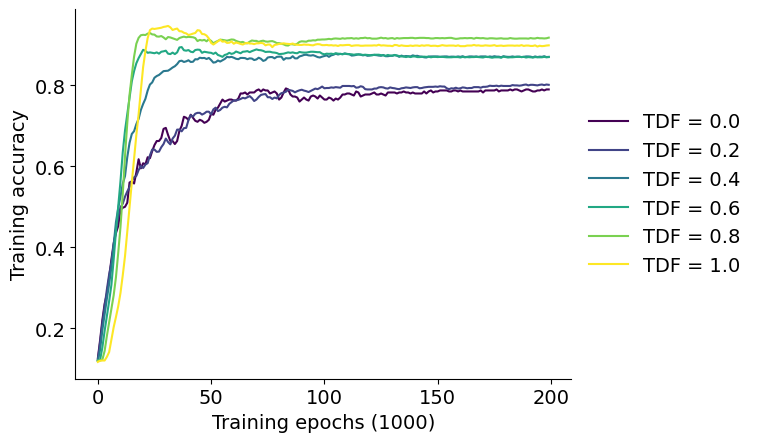

In [13]:
# training_accuracy_by_tdf = df_tdf[(df_tdf["pretrained"] == True) & (df_tdf["eta"] == 0.01)].groupby("temporal_discount_factor")["training_accuracy"].mean()
df_filtered = df[(df["accuracy"] > 0.7) & (df["noise_level"] == 1.0)]
training_accuracy_by_tdf = df_filtered.groupby("temporal_discount_factor")["training_accuracy"].mean()

colors = plt.cm.viridis(np.linspace(0, 1, len(training_accuracy_by_tdf)))
for i, (tdf, acc) in enumerate(training_accuracy_by_tdf.items()):
    plt.plot(acc[:200], label=f"TDF = {tdf:.1f}", color=colors[i])
    # std_dev = np.std(np.stack(df_tdf_filtered[df_tdf_filtered["temporal_discount_factor"] == tdf]["training_accuracy"]), axis=0)
    # plt.fill_between(range(len(acc[:200])), acc[:200] - std_dev, acc[:200] + std_dev, color=colors[i], alpha=0.2)
    
# set the legend to the right of the plot
ax = plt.gca()
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.xlabel("Training epochs (1000)")
plt.ylabel("Training accuracy")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()


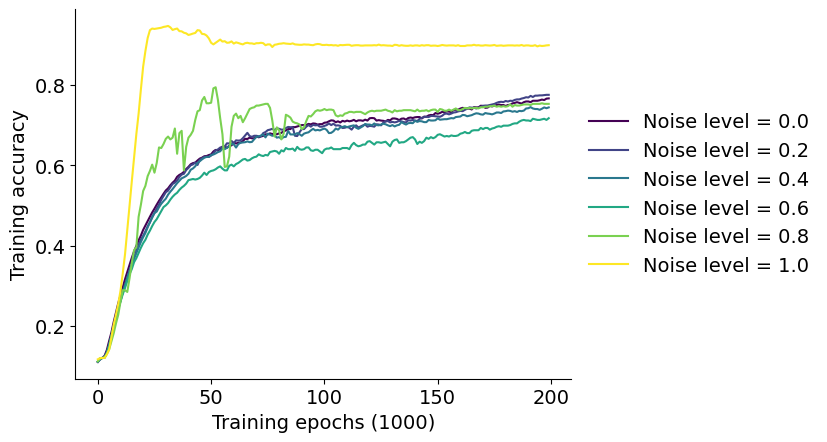

In [14]:
# training_accuracy_by_tdf = df_tdf[(df_tdf["pretrained"] == True) & (df_tdf["eta"] == 0.01)].groupby("temporal_discount_factor")["training_accuracy"].mean()
df_filtered = df[(df["accuracy"] > 0.7) & (df["temporal_discount_factor"] == 1.0)]
training_accuracy_by_tdf = df_filtered.groupby("noise_level")["training_accuracy"].mean()

colors = plt.cm.viridis(np.linspace(0, 1, len(training_accuracy_by_tdf)))
for i, (noise_level, acc) in enumerate(training_accuracy_by_tdf.items()):
    plt.plot(acc[:200], label=f"Noise level = {noise_level:.1f}", color=colors[i])
    # std_dev = np.std(np.stack(df_tdf_filtered[df_tdf_filtered["temporal_discount_factor"] == tdf]["training_accuracy"]), axis=0)
    # plt.fill_between(range(len(acc[:200])), acc[:200] - std_dev, acc[:200] + std_dev, color=colors[i], alpha=0.2)
    
# set the legend to the right of the plot
ax = plt.gca()
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.xlabel("Training epochs (1000)")
plt.ylabel("Training accuracy")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()


### influencing parameters of strategy

In [15]:
df_filtered = df[(df["accuracy"] > 0.7) & (df["temporal_factor"] >=0.4)]
#  & (df_tdf["temporal_factor"] >=0.4)
print(len(df_filtered))

467


In [16]:
df_tdf_filtered = df[(df["accuracy"] > 0.7) & (df["noise_level"] == 1.0)]
print(len(df_tdf_filtered))

96


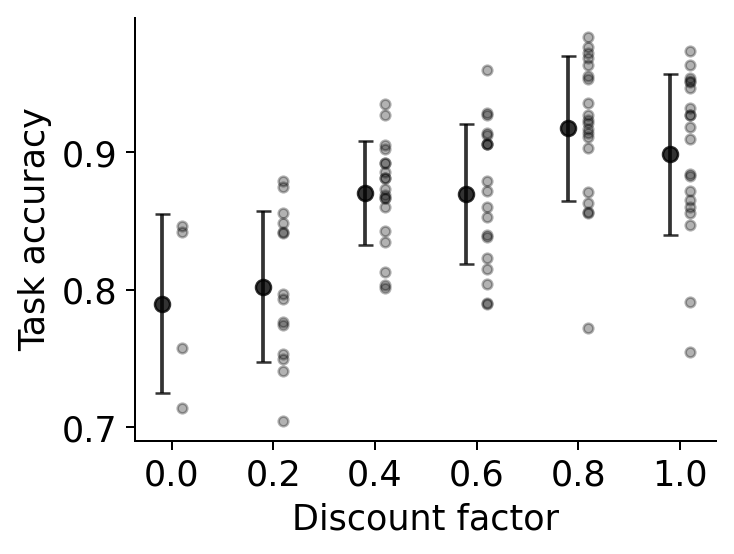

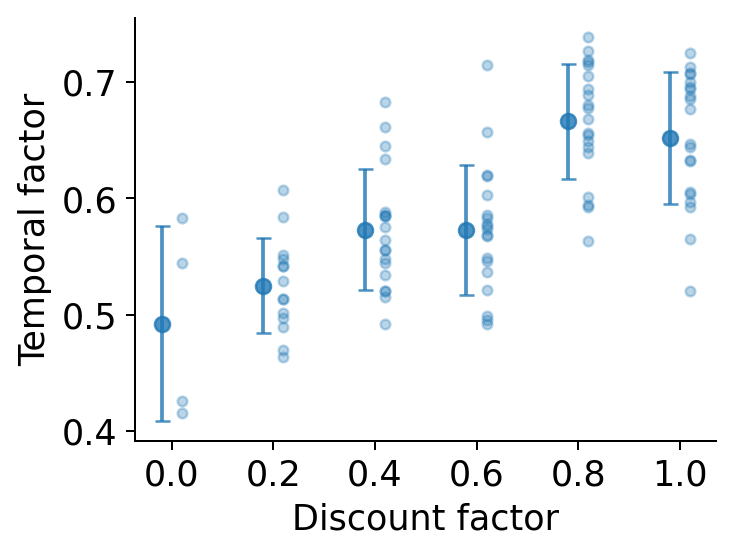

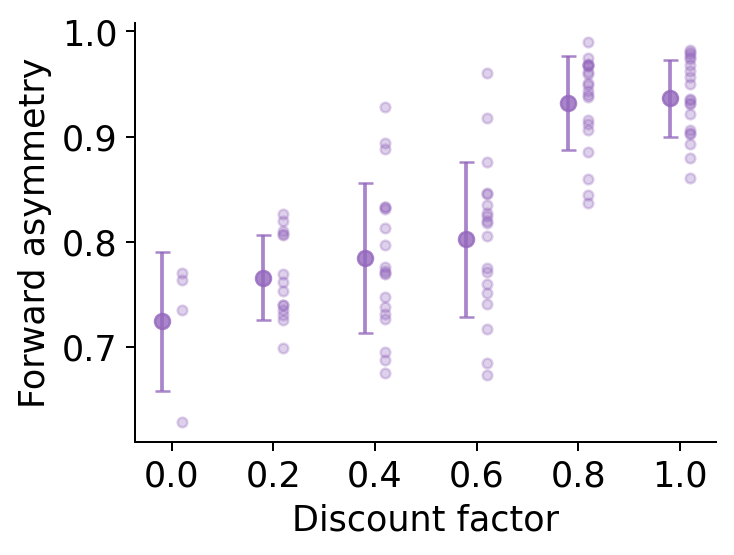

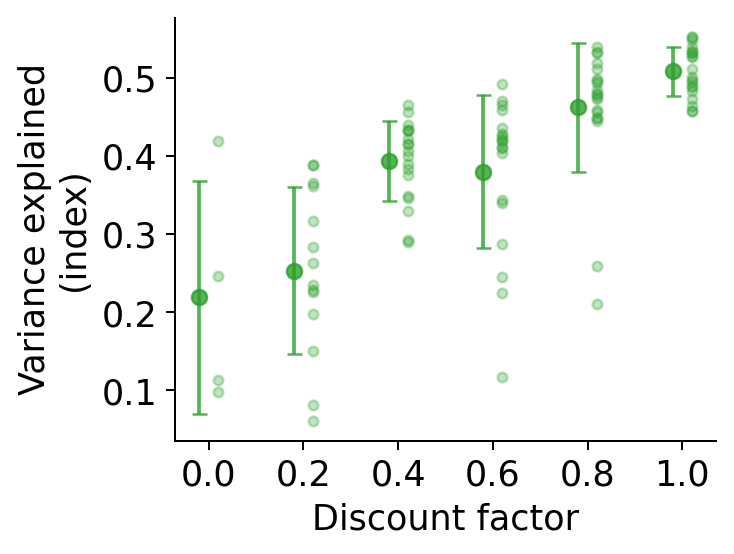

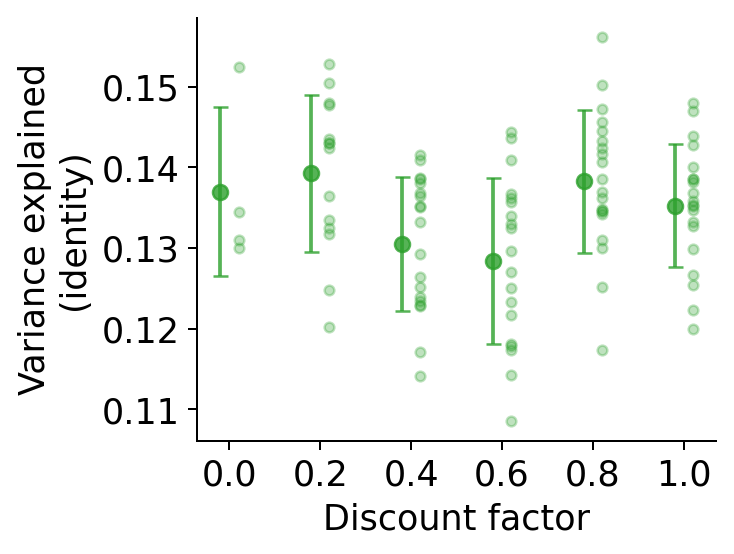

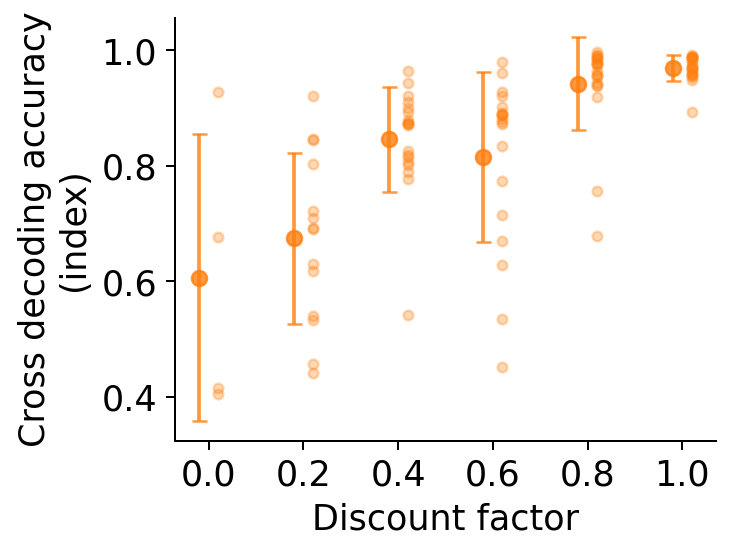

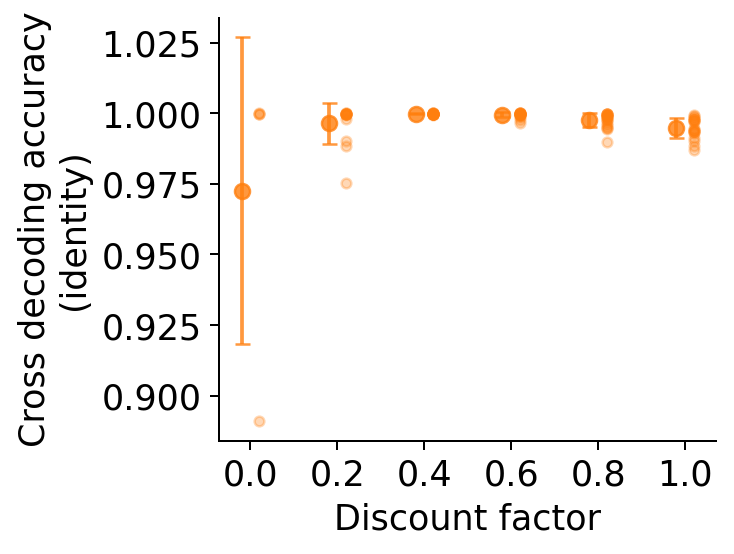

In [17]:
accuracy_mean_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["accuracy"].mean()
accuracy_std_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["accuracy"].std()

temporal_factor_mean_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["temporal_factor"].mean()
temporal_factor_std_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["temporal_factor"].std()

forward_asymmetry_mean_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["forward_asymmetry"].mean()
forward_asymmetry_std_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["forward_asymmetry"].std()

tdf_all = df_tdf_filtered["temporal_discount_factor"]
accuracy_all = df_tdf_filtered["accuracy"]
forward_asymmetry_all = df_tdf_filtered["forward_asymmetry"]
temporal_factor_all = df_tdf_filtered["temporal_factor"]
temporal_discount_factors = df_tdf_filtered["temporal_discount_factor"].unique()


plot_mean_std_scatter(temporal_discount_factors, accuracy_mean_by_tdf, accuracy_std_by_tdf, tdf_all, accuracy_all, "Discount factor", "Task accuracy", color=colormap["accuracy"])
plot_mean_std_scatter(temporal_discount_factors, temporal_factor_mean_by_tdf, temporal_factor_std_by_tdf, tdf_all, temporal_factor_all, "Discount factor", "Temporal factor", color=colormap["temporal_factor"])
plot_mean_std_scatter(temporal_discount_factors, forward_asymmetry_mean_by_tdf, forward_asymmetry_std_by_tdf, tdf_all, forward_asymmetry_all, "Discount factor", "Forward asymmetry", color=colormap["forward_asymmetry"])



# change with tdf
tdf_all = df_tdf_filtered["temporal_discount_factor"]
accuracy_all = df_tdf_filtered["accuracy"]
forward_asymmetry_all = df_tdf_filtered["forward_asymmetry"]
temporal_factor_all = df_tdf_filtered["temporal_factor"]
variance_explained_index_all = df_tdf_filtered["explained_variance_index"]
variance_explained_identity_all = df_tdf_filtered["explained_variance_identity"]
cross_decoding_accuracy_index_all = df_tdf_filtered["cross_decoding_accuracy_index"]
cross_decoding_accuracy_identity_all = df_tdf_filtered["cross_decoding_accuracy_identity"]

variance_explained_index_mean_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["explained_variance_index"].mean()
variance_explained_identity_mean_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["explained_variance_identity"].mean()
cross_decoding_accuracy_index_mean_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["cross_decoding_accuracy_identity"].mean()

variance_explained_index_std_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["explained_variance_index"].std()
variance_explained_identity_std_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["explained_variance_identity"].std()
cross_decoding_accuracy_index_std_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["cross_decoding_accuracy_index"].std()
cross_decoding_accuracy_identity_std_by_tdf = df_tdf_filtered.groupby("temporal_discount_factor")["cross_decoding_accuracy_identity"].std()


plot_mean_std_scatter(temporal_discount_factors, variance_explained_index_mean_by_tdf, variance_explained_index_std_by_tdf, 
                      tdf_all, variance_explained_index_all, "Discount factor", "Variance explained\n(index)", color=colormap["explained_variance"])

plot_mean_std_scatter(temporal_discount_factors, variance_explained_identity_mean_by_tdf, variance_explained_identity_std_by_tdf, 
                      tdf_all, variance_explained_identity_all, "Discount factor", "Variance explained\n(identity)", color=colormap["explained_variance"])

plot_mean_std_scatter(temporal_discount_factors, cross_decoding_accuracy_index_mean_by_tdf, cross_decoding_accuracy_index_std_by_tdf, 
                      tdf_all, cross_decoding_accuracy_index_all, "Discount factor", "Cross decoding accuracy\n(index)", color=colormap["cross_decoding"])

plot_mean_std_scatter(temporal_discount_factors, cross_decoding_accuracy_identity_mean_by_tdf, cross_decoding_accuracy_identity_std_by_tdf, 
                      tdf_all, cross_decoding_accuracy_identity_all, "Discount factor", "Cross decoding accuracy\n(identity)", color=colormap["cross_decoding"])


In [18]:
df_noise_filtered = df[(df["accuracy"] > 0.65) & (df["temporal_discount_factor"] == 1.0)]
print(len(df_noise_filtered))

93


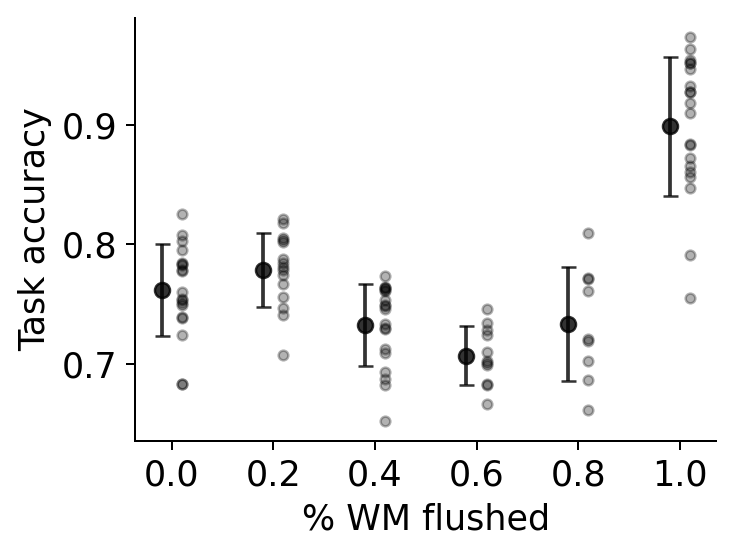

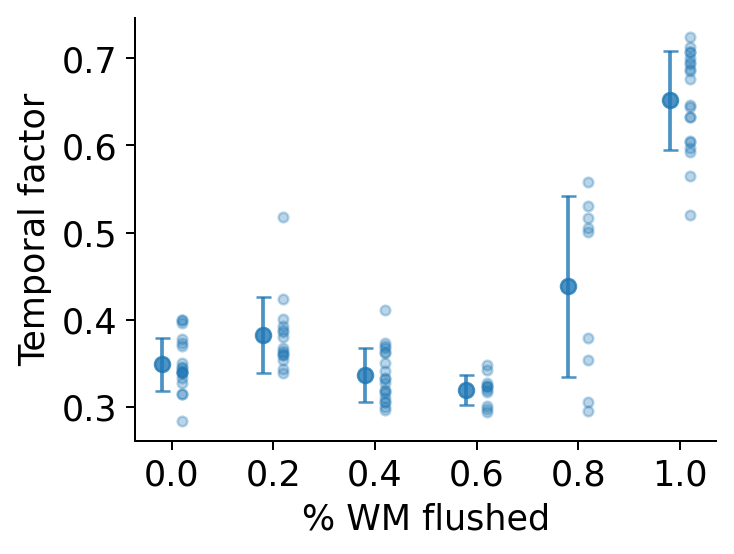

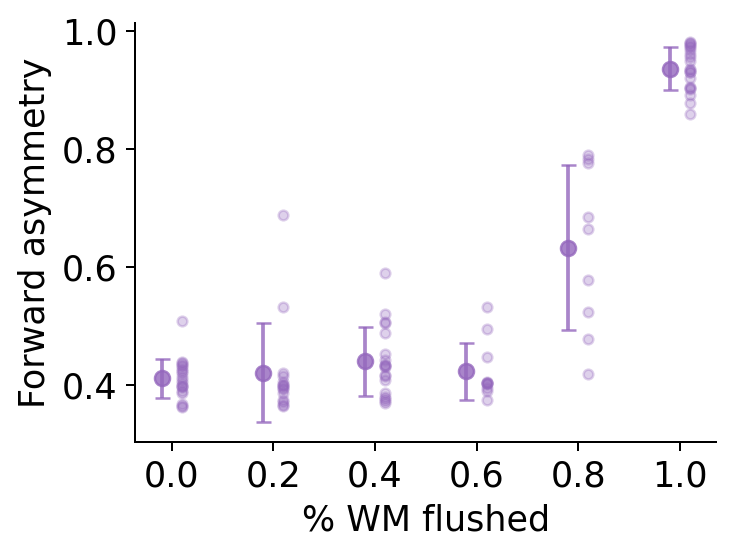

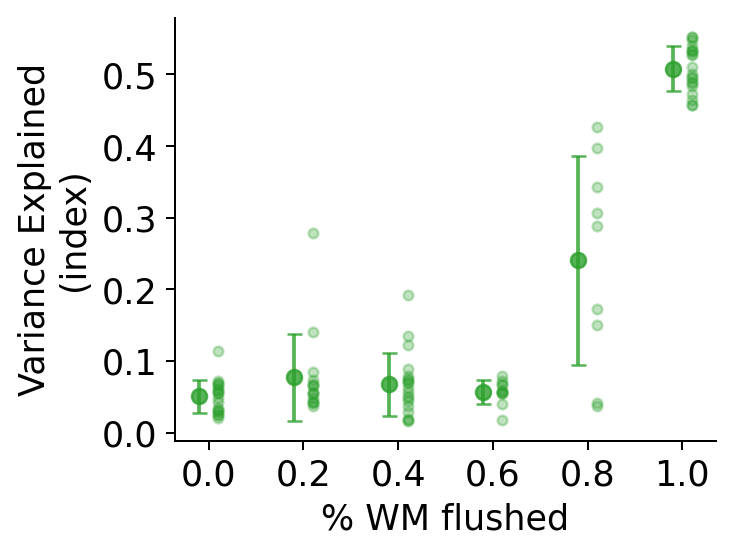

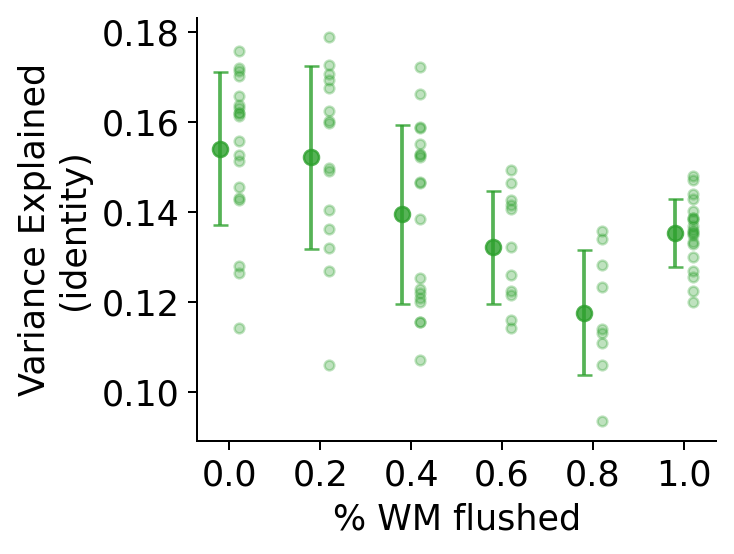

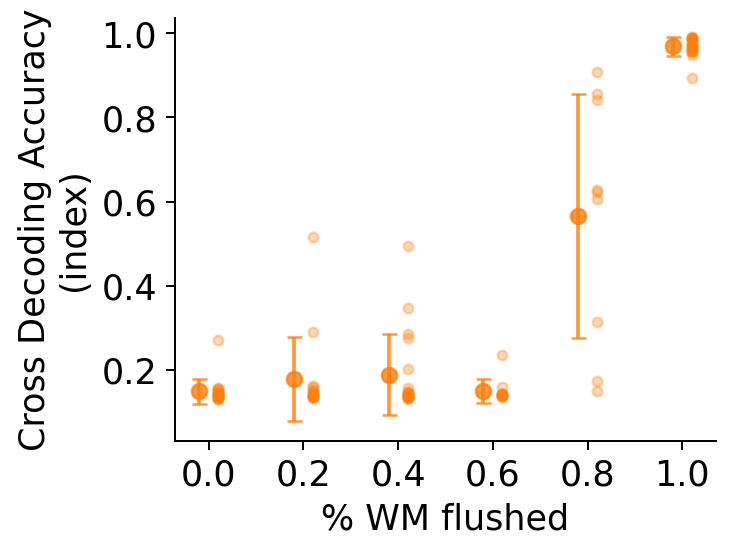

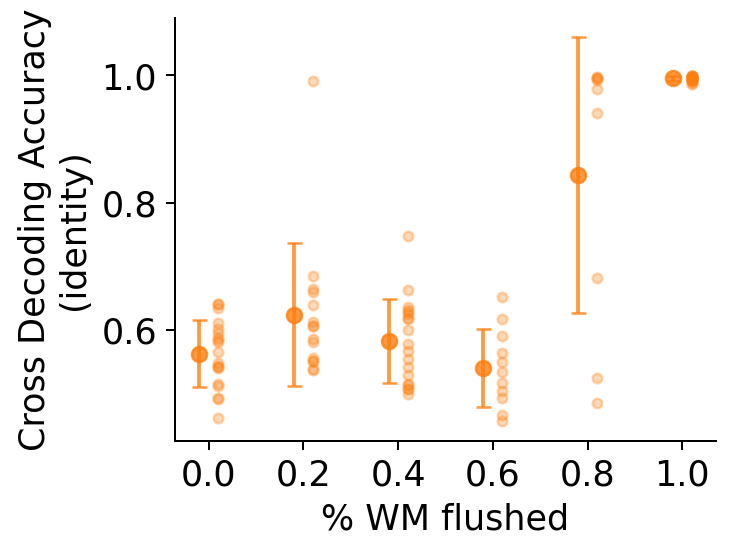

In [19]:
accuracy_mean_by_noise = df_noise_filtered.groupby("noise_level")["accuracy"].mean()
accuracy_std_by_noise = df_noise_filtered.groupby("noise_level")["accuracy"].std()

temporal_factor_mean_by_noise = df_noise_filtered.groupby("noise_level")["temporal_factor"].mean()
temporal_factor_std_by_noise = df_noise_filtered.groupby("noise_level")["temporal_factor"].std()

forward_asymmetry_mean_by_noise = df_noise_filtered.groupby("noise_level")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise = df_noise_filtered.groupby("noise_level")["forward_asymmetry"].std()

noise_all = df_noise_filtered["noise_level"]
accuracy_all = df_noise_filtered["accuracy"]
forward_asymmetry_all = df_noise_filtered["forward_asymmetry"]
temporal_factor_all = df_noise_filtered["temporal_factor"]
noise_levels = df_noise_filtered["noise_level"].unique()


plot_mean_std_scatter(temporal_discount_factors, accuracy_mean_by_noise, accuracy_std_by_noise, noise_all, accuracy_all, "% WM flushed", "Task accuracy", color=colormap['accuracy'])
plot_mean_std_scatter(temporal_discount_factors, temporal_factor_mean_by_noise, temporal_factor_std_by_noise, noise_all, temporal_factor_all, "% WM flushed", "Temporal factor", color=colormap["temporal_factor"])
plot_mean_std_scatter(temporal_discount_factors, forward_asymmetry_mean_by_noise, forward_asymmetry_std_by_noise, noise_all, forward_asymmetry_all, "% WM flushed", "Forward asymmetry", color=colormap["forward_asymmetry"])



variance_explained_index_all = df_noise_filtered["explained_variance_index"]
variance_explained_identity_all = df_noise_filtered["explained_variance_identity"]
cross_decoding_accuracy_index_all = df_noise_filtered["cross_decoding_accuracy_index"]
cross_decoding_accuracy_identity_all = df_noise_filtered["cross_decoding_accuracy_identity"]

variance_explained_index_mean_by_noise = df_noise_filtered.groupby("noise_level")["explained_variance_index"].mean()
variance_explained_index_std_by_noise = df_noise_filtered.groupby("noise_level")["explained_variance_index"].std()
variance_explained_identity_mean_by_noise = df_noise_filtered.groupby("noise_level")["explained_variance_identity"].mean()
variance_explained_identity_std_by_noise = df_noise_filtered.groupby("noise_level")["explained_variance_identity"].std()

cross_decoding_accuracy_index_mean_by_noise = df_noise_filtered.groupby("noise_level")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_index_std_by_noise = df_noise_filtered.groupby("noise_level")["cross_decoding_accuracy_index"].std()
cross_decoding_accuracy_identity_mean_by_noise = df_noise_filtered.groupby("noise_level")["cross_decoding_accuracy_identity"].mean()
cross_decoding_accuracy_identity_std_by_noise = df_noise_filtered.groupby("noise_level")["cross_decoding_accuracy_identity"].std()


plot_mean_std_scatter(noise_levels, variance_explained_index_mean_by_noise, variance_explained_index_std_by_noise, noise_all, variance_explained_index_all, "% WM flushed", "Variance Explained\n(index)", colormap["explained_variance"])
plot_mean_std_scatter(noise_levels, variance_explained_identity_mean_by_noise, variance_explained_identity_std_by_noise, noise_all, variance_explained_identity_all, "% WM flushed", "Variance Explained\n(identity)", colormap["explained_variance"])
plot_mean_std_scatter(noise_levels, cross_decoding_accuracy_index_mean_by_noise, cross_decoding_accuracy_index_std_by_noise, noise_all, cross_decoding_accuracy_index_all, "% WM flushed", "Cross Decoding Accuracy\n(index)", colormap["cross_decoding"])
plot_mean_std_scatter(noise_levels, cross_decoding_accuracy_identity_mean_by_noise, cross_decoding_accuracy_identity_std_by_noise, noise_all, cross_decoding_accuracy_identity_all, "% WM flushed", "Cross Decoding Accuracy\n(identity)", colormap["cross_decoding"])


### clustering

In [154]:
# df_filtered = df[(df["accuracy"]>0.65) & (df["temporal_factor"] >= 0.4)]


df_filtered = df[(df["accuracy"] > 0.5)]
# df_filtered = df[((df["temporal_discount_factor"] == 1.0) | (df["noise_level"] == 1.0)) & (df["accuracy"] > 0.5)]
print(len(df_filtered))

691


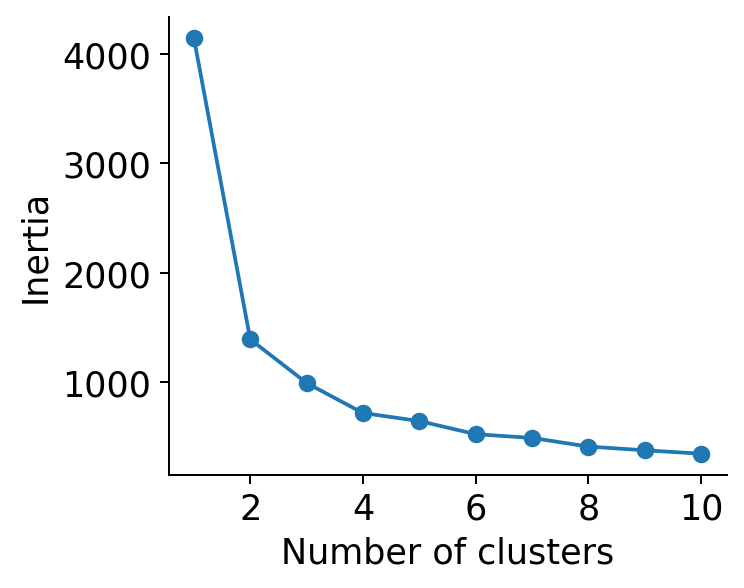

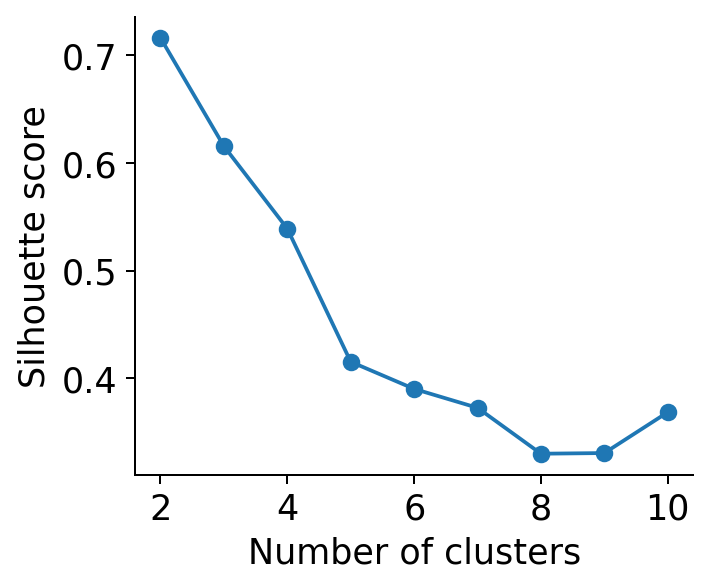

In [157]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["forward_asymmetry", "temporal_factor",
            # "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy", 
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity"]

X = df_filtered[features]

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Determine the optimal number of clusters with elbow method
inertia = []
sihoutte_score = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_normalized)
    labels = kmeans.labels_
    inertia.append(kmeans.inertia_)
    if n_clusters > 1:
        sihoutte_score.append(silhouette_score(X_normalized, labels))

plt.figure(figsize=(4, 3.3), dpi=180)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.title('Inertia for Optimal Number of Clusters')
plt.show()

plt.figure(figsize=(4, 3.3), dpi=180)
plt.plot(range(2, 11), sihoutte_score, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [158]:
# make the optimal number of clusters\

# Fit the KMeans model with the optimal number of clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_normalized)
df_filtered.loc[:, 'cluster'] = cluster_labels

# Add silhouette score to evaluate clustering quality
silhouette_avg = silhouette_score(X_normalized, cluster_labels)
print(f'Silhouette Score for {optimal_clusters} clusters: {silhouette_avg}')



Silhouette Score for 3 clusters: 0.6155310858003222


In [159]:
# print number of items for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}: {len(df_filtered[df_filtered["cluster"] == i])} items')
# print 5 info for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}:')
    print(df_filtered[df_filtered['cluster'] == i][["temporal_discount_factor", "noise_level", "model_num"]].tail())

Cluster 1: 534 items
Cluster 2: 98 items
Cluster 3: 59 items
Cluster 1:
     temporal_discount_factor  noise_level  model_num
651                       1.0          0.6         12
655                       1.0          0.6         16
658                       1.0          0.6         19
660                       1.0          0.8          1
665                       1.0          0.8          6
Cluster 2:
     temporal_discount_factor  noise_level  model_num
694                       1.0          1.0         15
695                       1.0          1.0         16
696                       1.0          1.0         17
697                       1.0          1.0         18
698                       1.0          1.0         19
Cluster 3:
     temporal_discount_factor  noise_level  model_num
669                       1.0          0.8         10
671                       1.0          0.8         12
672                       1.0          0.8         13
675                       1.0          0.8

In [160]:
df_filtered = df_filtered[((df_filtered["temporal_discount_factor"] == 1.0) | (df_filtered["noise_level"] == 1.0))]
print(len(df_filtered))

209


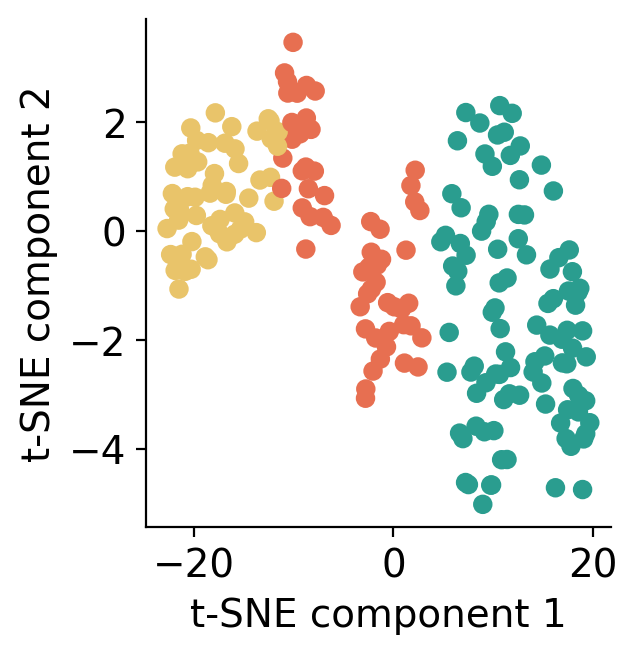

In [177]:
from sklearn.manifold import TSNE

colormap = np.array(["#E9C46A", "#2A9D8F", "#E76F51", "#F4A261", "#264653"])


features = ["forward_asymmetry", "temporal_factor",
            # "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy", 
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity"]

X_tsne = df_filtered[features]

scaler = StandardScaler()
X_tsne_normalized = scaler.fit_transform(X_tsne)
cluster_labels = df_filtered["cluster"]

# Perform t-SNE on the normalized data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_normalized)

# Plot the t-SNE results with cluster labels
plt.figure(figsize=(3, 3.3), dpi=200)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colormap[cluster_labels])
# plt.title('t-SNE visualization of clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


In [ ]:
import seaborn as sns

features = ["forward_asymmetry", "temporal_factor",
            "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy", 
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity"]

# Calculate correlation matrix
correlation_matrix = df_filtered[features].corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 12), dpi=200)
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True, square=True)
plt.title('Feature Correlation Matrix')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


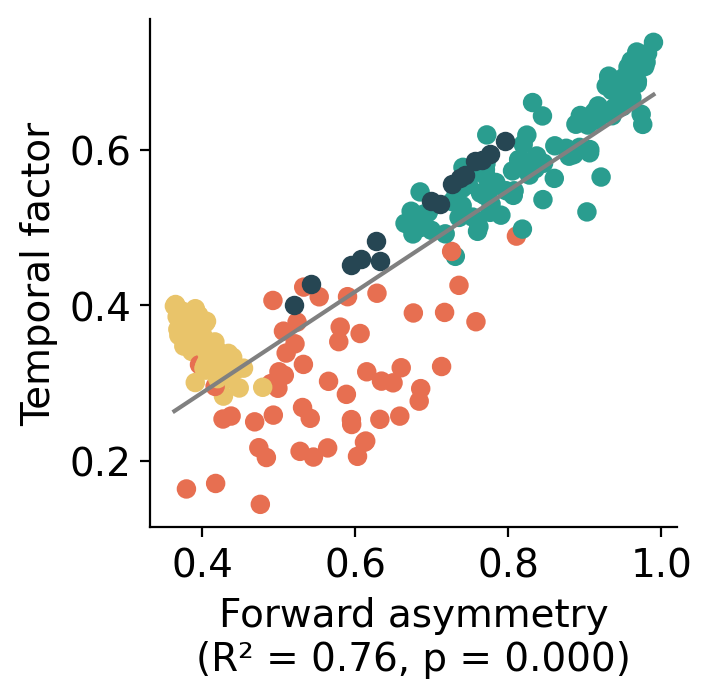

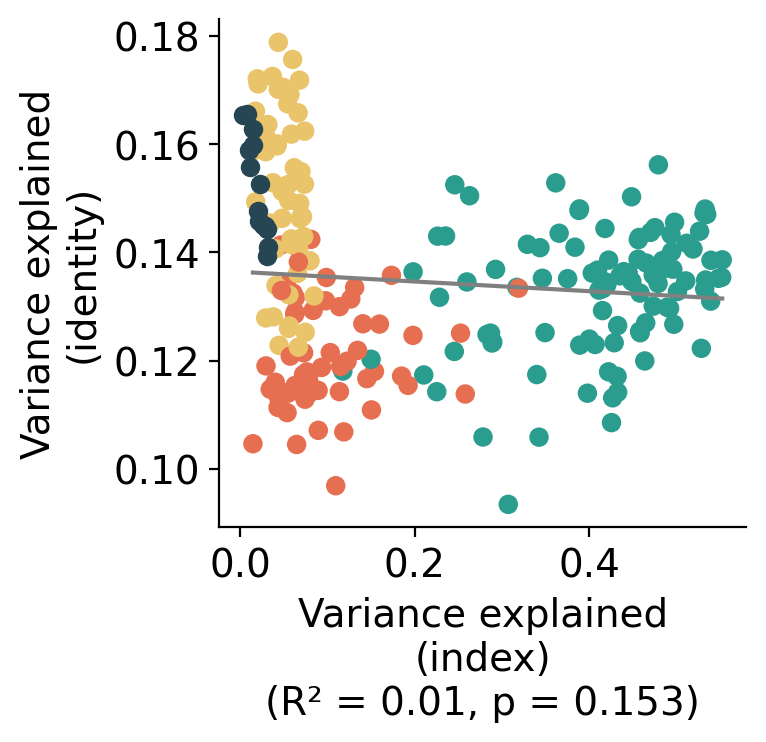

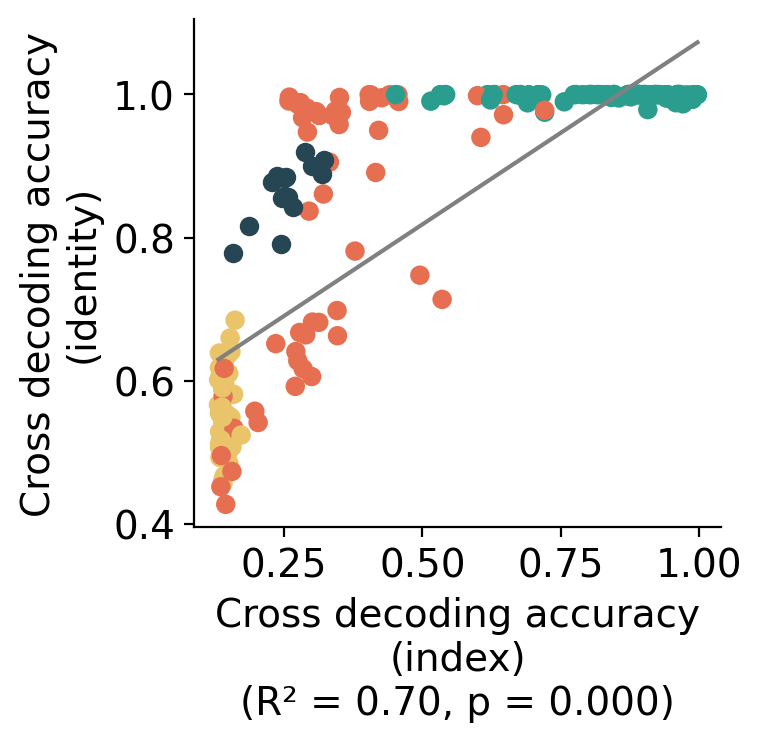

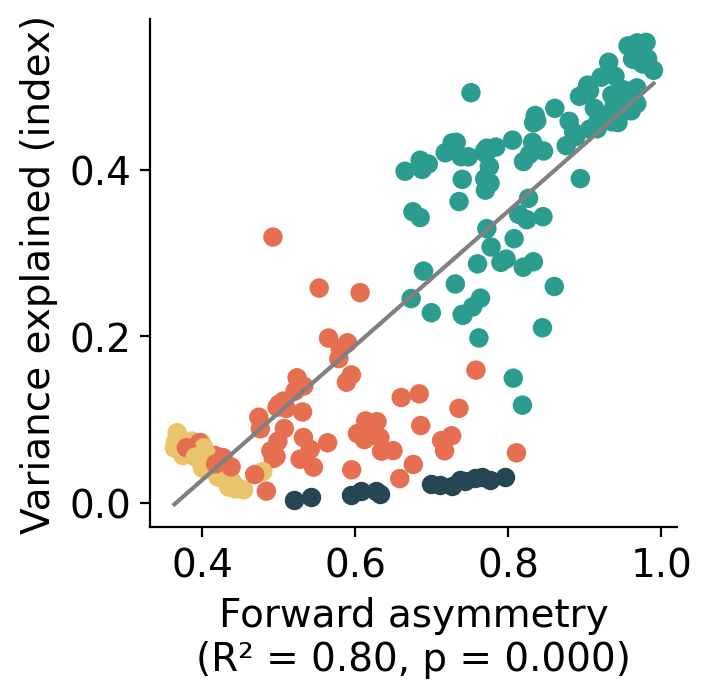

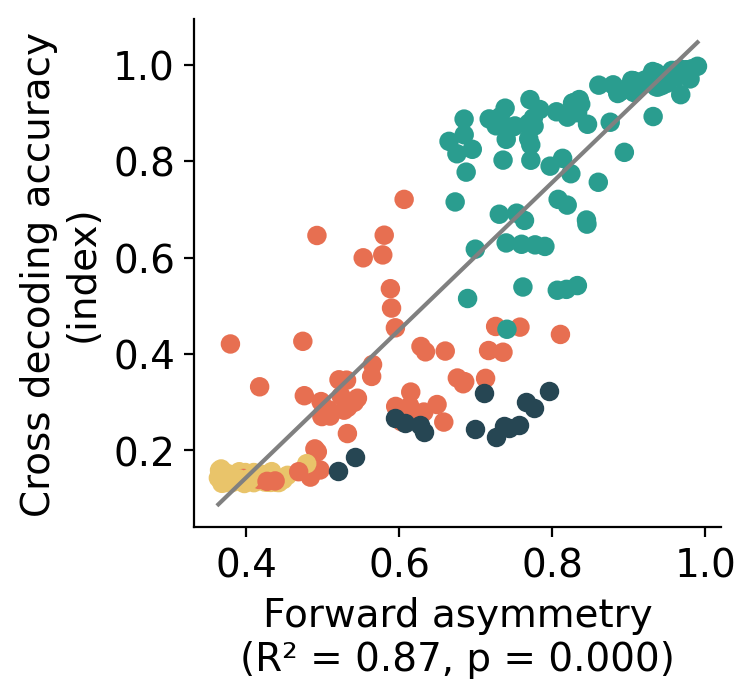

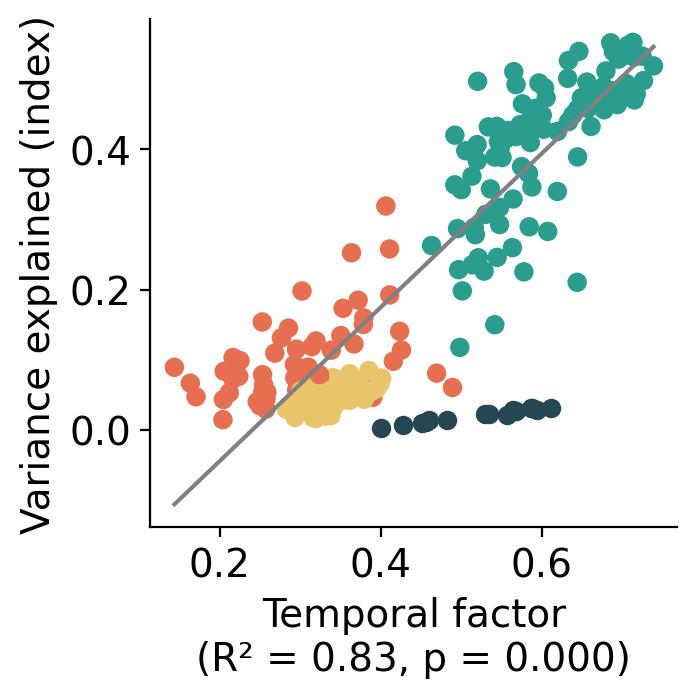

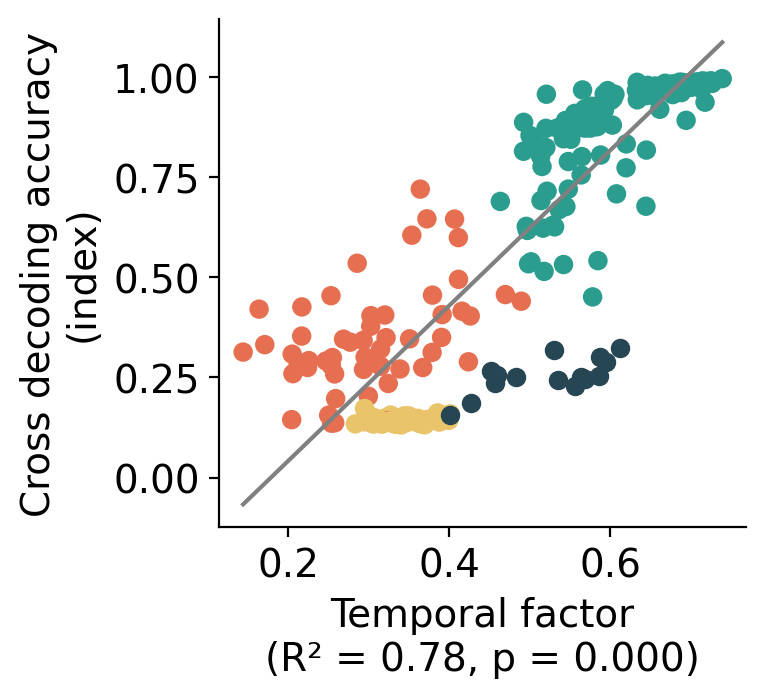

In [178]:
# plot scatter with cluster labels

def plot_scatter_cluster(df, x, y, c, x_label, y_label, fit=True, plot_reservoir=True):
    plt.figure(figsize=(3.4, 3.3), dpi=200)

    plt.scatter(df[x], df[y], c=colormap[df[c].iloc[:]])

    if fit:
        if plot_reservoir:
            # plot for reservoir and tcm
            plt.scatter(df_reservoir[x], df_reservoir[y], c=colormap[-1])
            # plt.scatter(df_tcm[x], df_tcm[y], c=colormap[-1])
    
        # Reshape x and y for sklearn
        x_reshaped = np.array(df[x]).reshape(-1, 1)
        y_reshaped = np.array(df[y]).reshape(-1, 1)

        # Fit linear regression model
        model = LinearRegression()
        model.fit(x_reshaped, y_reshaped)

        # Predict y values
        sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
        x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
        y_pred = model.predict(x_reshaped)
        y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

        # Calculate R-squared
        r2 = r2_score(y_reshaped, y_pred)
        # Calculate the p-value for the regression
        _, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())
        
        # Plot the regression line
        plt.plot([x1, x2], [y1, y2], color="grey")

        x_label = x_label+"\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value)

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # plt.tight_layout()
    plt.show()

plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'temporal_factor', 'cluster', 'Forward asymmetry', 'Temporal factor')
plot_scatter_cluster(df_filtered, 'explained_variance_index', 'explained_variance_identity', 'cluster', 'Variance explained\n(index)', 'Variance explained\n(identity)')
plot_scatter_cluster(df_filtered, 'cross_decoding_accuracy_index', 'cross_decoding_accuracy_identity', 'cluster', 'Cross decoding accuracy\n(index)', 'Cross decoding accuracy\n(identity)')

plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'explained_variance_index', 'cluster', 'Forward asymmetry', 'Variance explained (index)')
plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'cross_decoding_accuracy_index', 'cluster', 'Forward asymmetry', 'Cross decoding accuracy\n(index)')

plot_scatter_cluster(df_filtered, 'temporal_factor', 'explained_variance_index', 'cluster', 'Temporal factor', 'Variance explained (index)')
plot_scatter_cluster(df_filtered, 'temporal_factor', 'cross_decoding_accuracy_index', 'cluster', 'Temporal factor', 'Cross decoding accuracy\n(index)')


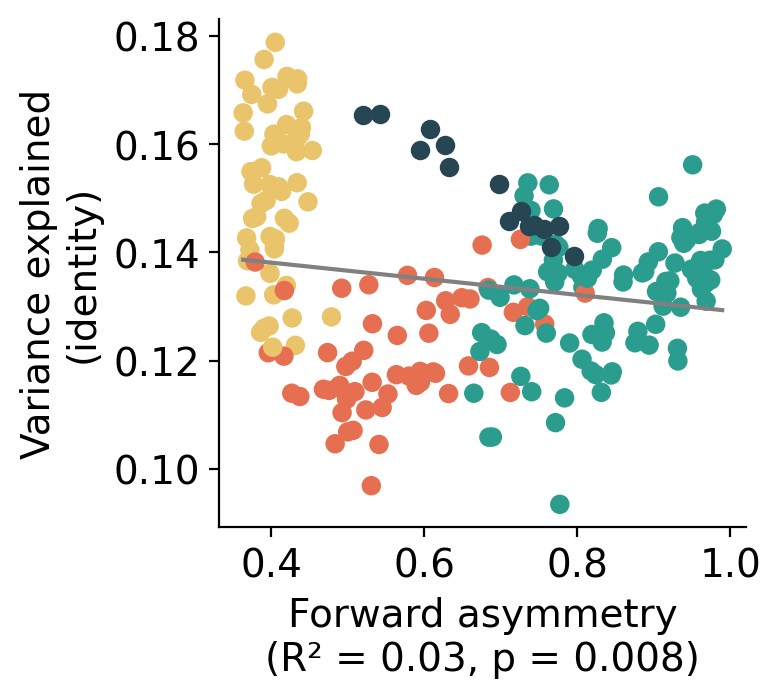

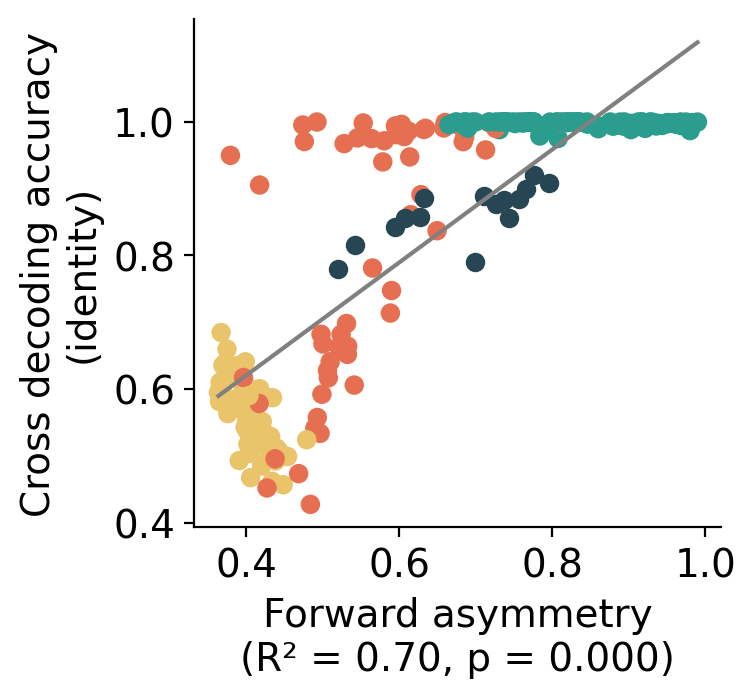

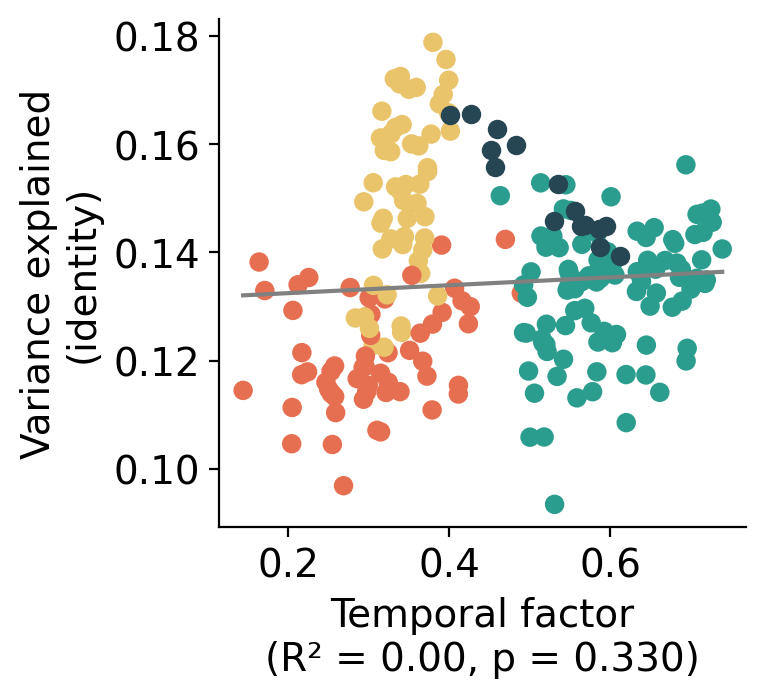

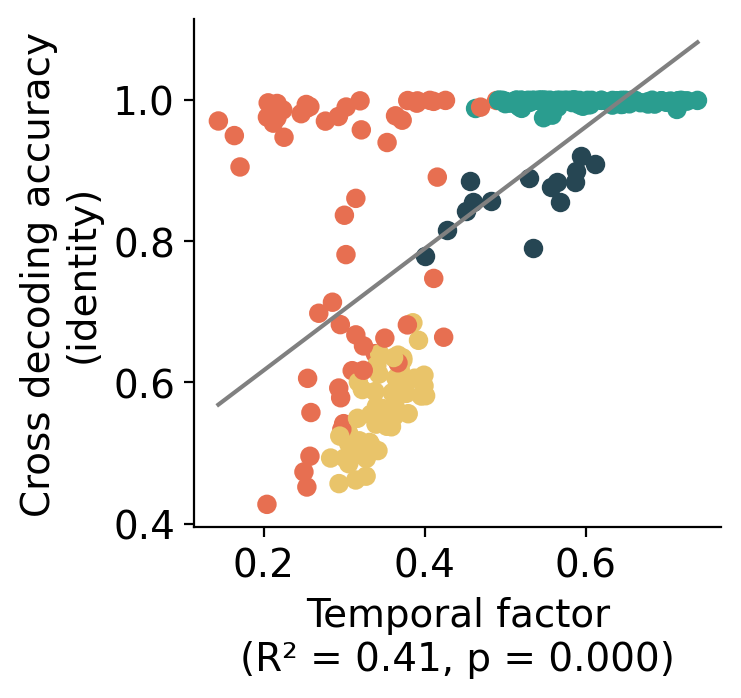

In [165]:
plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'explained_variance_identity', 'cluster', 'Forward asymmetry', 'Variance explained\n(identity)')
plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'cross_decoding_accuracy_identity', 'cluster', 'Forward asymmetry', 'Cross decoding accuracy\n(identity)')

plot_scatter_cluster(df_filtered, 'temporal_factor', 'explained_variance_identity', 'cluster', 'Temporal factor', 'Variance explained\n(identity)')
plot_scatter_cluster(df_filtered, 'temporal_factor', 'cross_decoding_accuracy_identity', 'cluster', 'Temporal factor', 'Cross decoding accuracy\n(identity)')

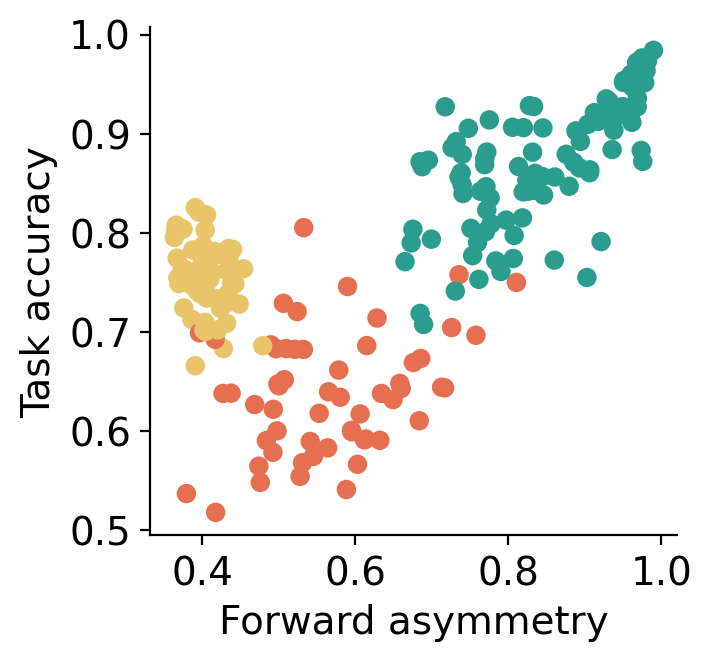

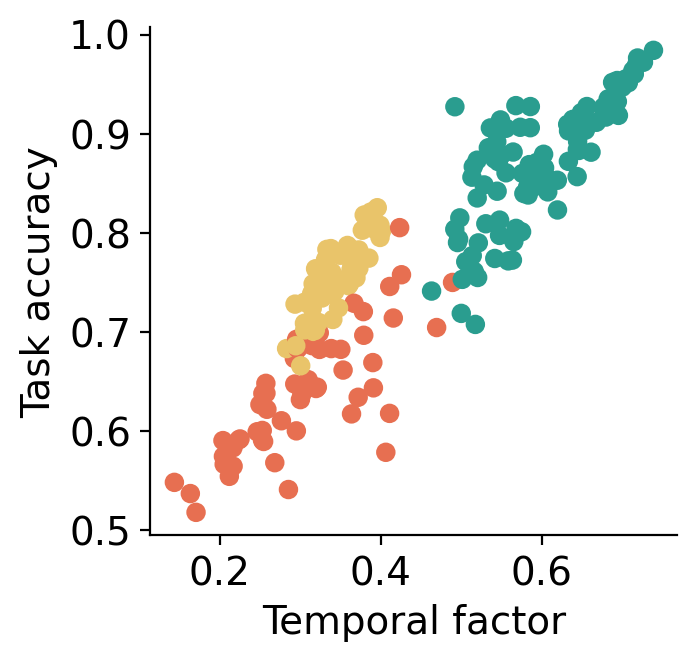

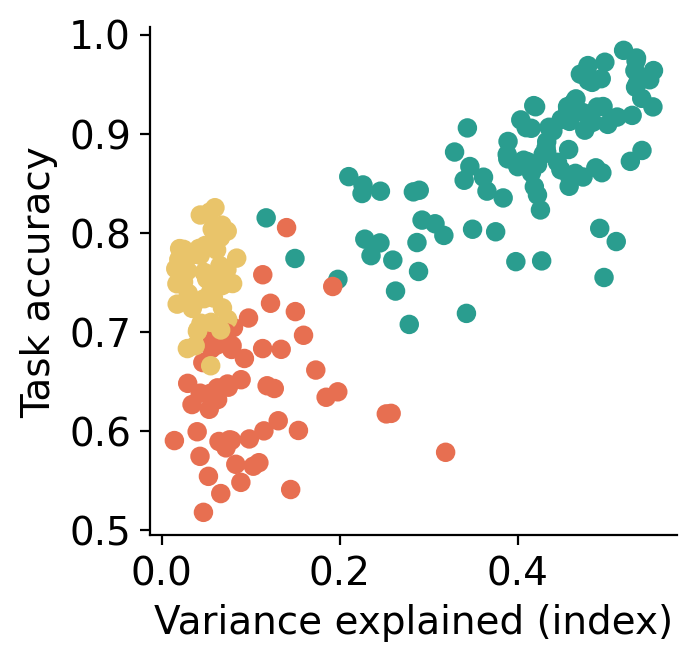

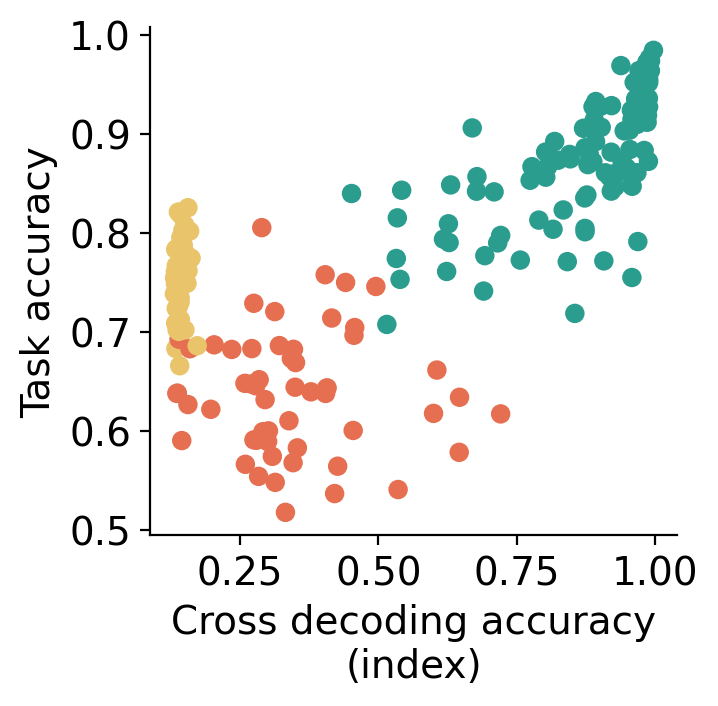

In [166]:
plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'accuracy', 'cluster', 'Forward asymmetry', 'Task accuracy', fit=False)
plot_scatter_cluster(df_filtered, 'temporal_factor', 'accuracy', 'cluster', 'Temporal factor', 'Task accuracy', fit=False)
plot_scatter_cluster(df_filtered, 'explained_variance_index', 'accuracy', 'cluster', 'Variance explained (index)', 'Task accuracy', fit=False)
plot_scatter_cluster(df_filtered, 'cross_decoding_accuracy_index', 'accuracy', 'cluster', 'Cross decoding accuracy\n(index)', 'Task accuracy', fit=False)

In [ ]:
# relation between variance explained by index and identity, with broken axis

y1_min, y1_max = 0.42, 0.56
y2_min, y2_max = 0.05, 0.25

range1 = y1_max - y1_min
range2 = y2_max - y2_min
scale = range1 / range2 / 2

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(4.3, 3.3), dpi=200, gridspec_kw={'height_ratios': [range1/2, range2]})

ax1.scatter(df_filtered['explained_variance_index'], df_filtered['explained_variance_identity'], c=colormap[df_filtered['cluster'].iloc[:]])
ax1.scatter(df_reservoir['explained_variance_index'], df_reservoir['explained_variance_identity'], c=colormap[-2])
ax1.scatter(df_tcm['explained_variance_index'], df_tcm['explained_variance_identity'], c=colormap[-1])

ax2.scatter(df_filtered['explained_variance_index'], df_filtered['explained_variance_identity'], c=colormap[df_filtered['cluster'].iloc[:]])
ax2.scatter(df_reservoir['explained_variance_index'], df_reservoir['explained_variance_identity'], c=colormap[-2])
ax2.scatter(df_tcm['explained_variance_index'], df_tcm['explained_variance_identity'], c=colormap[-1])

ax1.set_ylim(y1_min, y1_max)
ax2.set_ylim(y2_min, y2_max)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['bottom'].set_visible(False)
ax1.xaxis.set_visible(False)
ax1.set_yticks([0.45, 0.55])
# ax1.xaxis.tick_top()
# ax1.tick_params(labeltop=False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.xaxis.tick_bottom()
ax2.set_yticks([0.05, 0.15, 0.25])


d = 0.015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((-d, +d), (-d/scale, +d/scale), **kwargs)        # top-left diagonal
# ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)  # top-right diagonal

kwargs.update(transform=ax2.transAxes)  # switch to the bottom axes
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)  # bottom-left diagonal
# ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)  # bottom-right diagonal


# Reshape x and y for sklearn
x_reshaped = np.array(df_filtered['explained_variance_index']).reshape(-1, 1)
y_reshaped = np.array(df_filtered['explained_variance_identity']).reshape(-1, 1)

# Fit linear regression model
model = LinearRegression()
model.fit(x_reshaped, y_reshaped)

# Predict y values
sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
y_pred = model.predict(x_reshaped)
y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

# Calculate R-squared
r2 = r2_score(y_reshaped, y_pred)
# Calculate the p-value for the regression
_, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())

# Plot the regression line
ax2.plot([x1, x2], [y1, y2], color="grey")

ax2.set_xlabel("Variance explained (index)\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value))
ax2.set_ylabel("Variance explained\n(identity)")

plt.show()


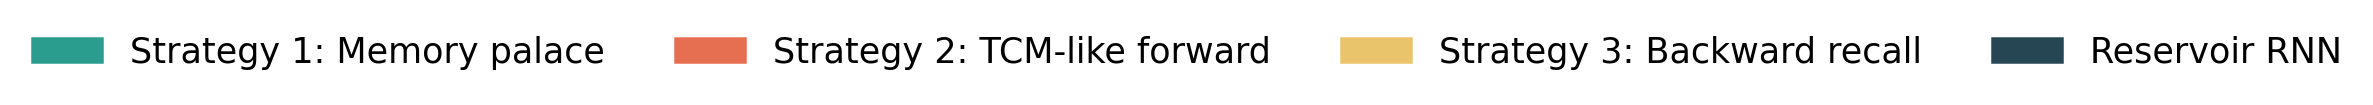

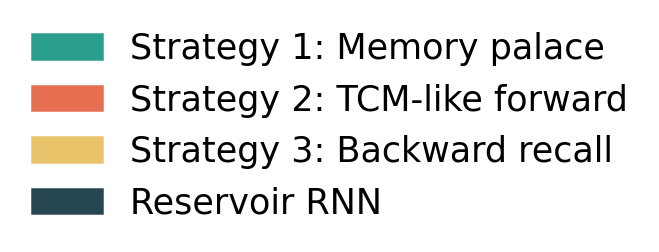

In [55]:
# Create a legend for the colormap
import matplotlib.patches as mpatches

# Define labels for the legend
legend_labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

# Create a list of patches for the legend
patches = [mpatches.Patch(color="#2A9D8F", label="Strategy 1: Memory palace"),
           mpatches.Patch(color="#E76F51", label="Strategy 2: TCM-like forward"),
           mpatches.Patch(color="#E9C46A", label="Strategy 3: Backward recall"),
           mpatches.Patch(color="#264653", label="Reservoir RNN")]
        #    mpatches.Patch(color="#264653", label="TCM")]
# [mpatches.Patch(color=colormap[i], label=legend_labels[i]) for i in range(optimal_clusters)]

# Plot the legend
plt.figure(figsize=(8, 0.5), dpi=180)
plt.legend(handles=patches, loc='center', ncol=optimal_clusters+1, frameon=False)
plt.axis('off')
plt.show()

plt.figure(figsize=(2, 0.5), dpi=180)
plt.legend(handles=patches, loc='center', frameon=False)
plt.axis('off')
plt.show()

In [ ]:
from sklearn.metrics import pairwise_distances_argmin_min
import numpy as np

# Calculate the contribution of each dimension to the clustering
def calculate_wcss_contribution(df, data, features, cluster_centers):
    # Initialize a dictionary to store WCSS contribution for each feature
    wcss_contribution = {feature.replace('_', ' '): 0 for feature in features}
    
    # Iterate over each cluster
    for i in range(optimal_clusters):
        # Get data points in the current cluster
        # cluster_data = df[df['cluster'] == i][features]
        cluster_data = data[df['cluster'] == i]
        
        # Calculate the distance of each point to the cluster center
        _, distances = pairwise_distances_argmin_min(cluster_data, [cluster_centers[i]])
        
        # Calculate the WCSS for each feature
        for j, feature in enumerate(features):
            feature_values = cluster_data[:, j]
            feature_center = cluster_centers[i][j]
            wcss_contribution[feature.replace('_', ' ')] += np.sum((feature_values - feature_center) ** 2)
    
    # Normalize the contributions to sum to 1
    total_wcss = sum(wcss_contribution.values())
    for feature in wcss_contribution:
        wcss_contribution[feature.replace('_', ' ')] /= total_wcss
    
    return wcss_contribution

# Define the features used for clustering
# features = ['forward_asymmetry', 'temporal_factor', 'explained_variance_index', 
#             'explained_variance_identity', 'cross_decoding_accuracy_index', 
#             'cross_decoding_accuracy_identity']

# Assuming cluster_centers is a list of cluster centers obtained from the clustering algorithm
cluster_centers = kmeans.cluster_centers_

X = df_filtered[features]

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Calculate WCSS contribution
wcss_contribution = calculate_wcss_contribution(df_filtered, X_normalized, features, cluster_centers)

# Print the contribution of each dimension
print("WCSS Contribution of each dimension:")
for feature, contribution in wcss_contribution.items():
    print(f"{feature}: {contribution:.4f}")

# Create a bar plot for the WCSS contribution of each dimension
plt.figure(figsize=(10, 6))
plt.bar(wcss_contribution.keys(), wcss_contribution.values(), color='grey')
plt.xlabel('Features')
plt.ylabel('WCSS Contribution')
plt.title('WCSS Contribution of Each Dimension')
plt.xticks(rotation=45, ha='right')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()



In [168]:
# distribution of strategies in each factor

def plot_bar_by_strategy(df, x, x_label):
    plt.figure(figsize=(3.2, 3.3), dpi=180)
    
    cluster_distribution = df.groupby(["cluster", x]).size().unstack(fill_value=0)
    sum_distribution = cluster_distribution.sum(axis=0)
    cluster_distribution = cluster_distribution.div(sum_distribution, axis=1)
    cumsum_distribution = cluster_distribution.cumsum(axis=0)

    for i, row in cumsum_distribution.iterrows():
        plt.bar(row.index, row.values, color=colormap[i], label=f"Cluster {i}", width=0.12, zorder=-i)
    plt.xlabel(x_label)
    plt.ylabel("Distribution of strategies")

    unique_x = df[x].unique()
    plt.xticks(unique_x, unique_x)
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()


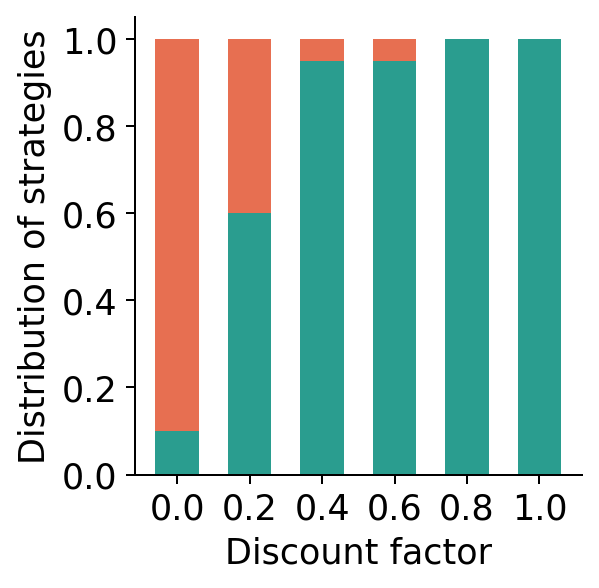

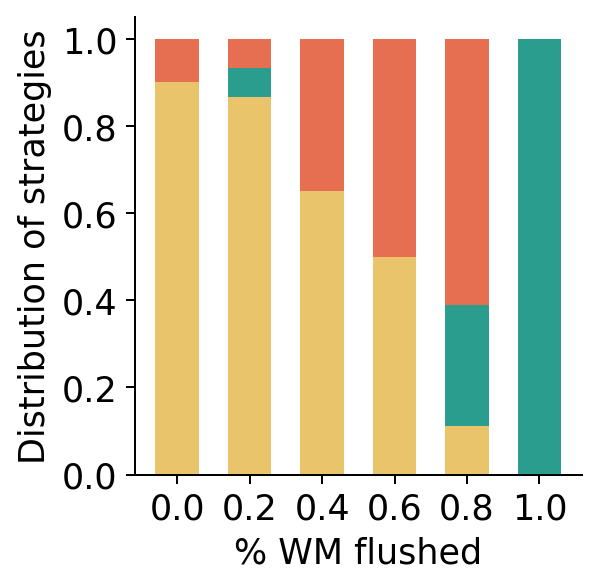

In [169]:
df_all_tdf = df_filtered[df_filtered["noise_level"] == 1.0]
# df_all_tdf = df_filtered
plot_bar_by_strategy(df_all_tdf, "temporal_discount_factor", "Discount factor")

df_all_noise = df_filtered[df_filtered["temporal_discount_factor"] == 1.0]
# df_all_noise = df_filtered
plot_bar_by_strategy(df_all_noise, "noise_level", "% WM flushed")

# plot_bar_by_strategy(df_filtered, "temporal_discount_factor", "Discount factor")
# plot_bar_by_strategy(df_filtered, "noise_level", "% WM flushed")


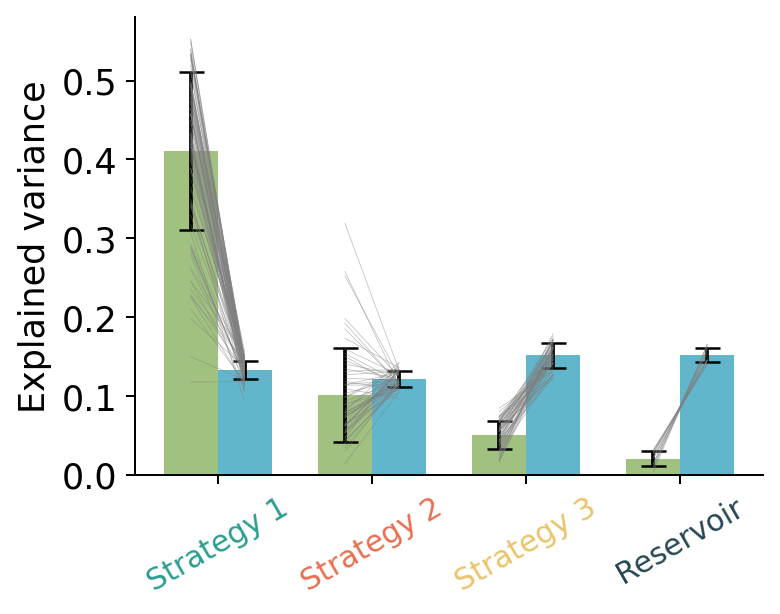

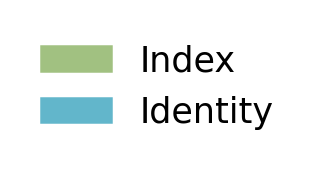

In [170]:
# mean explained variance of each strategy

mean_explained_variance_index = df_filtered.groupby("cluster")["explained_variance_index"].mean()
std_explained_variance_index = df_filtered.groupby("cluster")["explained_variance_index"].std()
mean_explained_variance_identity = df_filtered.groupby("cluster")["explained_variance_identity"].mean()
std_explained_variance_identity = df_filtered.groupby("cluster")["explained_variance_identity"].std()
mean_explained_variance_index_reservoir = df_reservoir["explained_variance_index"].mean()
std_explained_variance_index_reservoir = df_reservoir["explained_variance_index"].std()
mean_explained_variance_identity_reservoir = df_reservoir["explained_variance_identity"].mean()
std_explained_variance_identity_reservoir = df_reservoir["explained_variance_identity"].std()
# print(mean_explained_variance_index, std_explained_variance_index)
# print(mean_explained_variance_identity, std_explained_variance_identity)
mean_explained_variance_index = np.array(mean_explained_variance_index)
std_explained_variance_index = np.array(std_explained_variance_index)
mean_explained_variance_identity = np.array(mean_explained_variance_identity)
std_explained_variance_identity = np.array(std_explained_variance_identity)
mean_explained_variance_index = [mean_explained_variance_index[1], mean_explained_variance_index[2], mean_explained_variance_index[0],mean_explained_variance_index_reservoir]
std_explained_variance_index = [std_explained_variance_index[1], std_explained_variance_index[2], std_explained_variance_index[0],std_explained_variance_index_reservoir]
mean_explained_variance_identity = [mean_explained_variance_identity[1], mean_explained_variance_identity[2], mean_explained_variance_identity[0],mean_explained_variance_identity_reservoir]
std_explained_variance_identity = [std_explained_variance_identity[1], std_explained_variance_identity[2], std_explained_variance_identity[0],std_explained_variance_identity_reservoir]

plt.figure(figsize=(4.5, 3.3), dpi=180)
ax = plt.gca()
bar_width = 0.35
index = np.arange(4)
plt.bar(index, mean_explained_variance_index, bar_width, yerr=std_explained_variance_index, capsize=5, color="#A1C181")
plt.bar(index + bar_width, mean_explained_variance_identity, bar_width, yerr=std_explained_variance_identity, capsize=5, color="#62B6CB")
plt.xticks(index + bar_width / 2, ["Strategy 1", "Strategy 2", "Strategy 3", "Reservoir"], fontsize=12, rotation=30)
for xtick, color in zip(ax.get_xticklabels(), [colormap[1], colormap[2], colormap[0], colormap[-1]]):
    xtick.set_color(color)
plt.ylabel("Explained variance")
# plt.legend(["Index", "Identity"], frameon=False, fontsize=12)
for group, pos in zip([0,1,2], [2,0,1]):
    data = df_filtered[df_filtered["cluster"] == group]
    for i in range(len(data)):
        plt.plot([pos, pos+bar_width], [data["explained_variance_index"].iloc[i], data["explained_variance_identity"].iloc[i]], color='grey', linestyle='-', linewidth=0.3, alpha=0.5)
for i in range(len(df_reservoir)):
    plt.plot([3, 3+bar_width], [df_reservoir["explained_variance_index"].iloc[i], df_reservoir["explained_variance_identity"].iloc[i]], color='grey', linestyle='-', linewidth=0.3, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

import matplotlib.patches as mpatches
plt.figure(figsize=(2,1), dpi=180)
patches = [mpatches.Patch(color="#A1C181", label="Index"), mpatches.Patch(color="#62B6CB", label="Identity")]
plt.legend(handles=patches, loc='center', frameon=False)
plt.axis('off') 
plt.show()


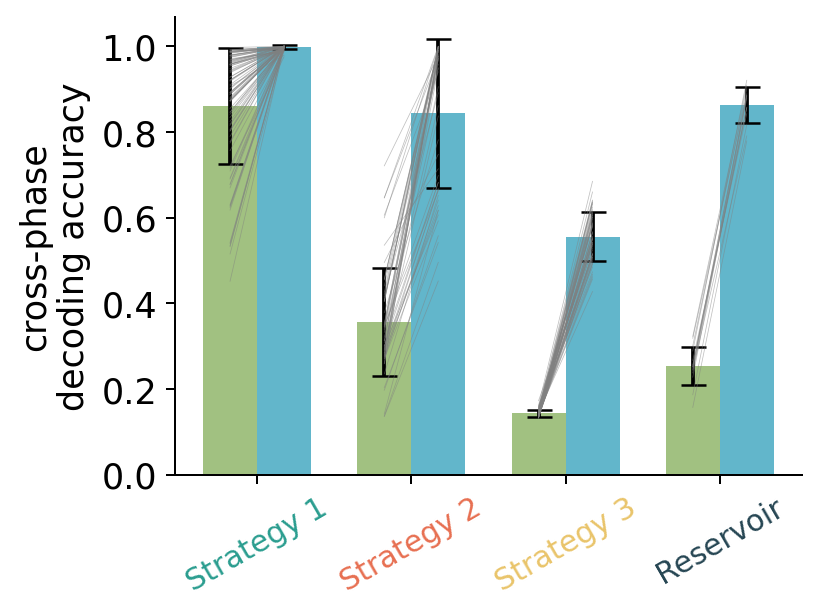

In [87]:
# mean cross decoding accuracy of each strategy

mean_cross_decoding_accuracy_index = df_filtered.groupby("cluster")["cross_decoding_accuracy_index"].mean()
std_cross_decoding_accuracy_index = df_filtered.groupby("cluster")["cross_decoding_accuracy_index"].std()
mean_cross_decoding_accuracy_identity = df_filtered.groupby("cluster")["cross_decoding_accuracy_identity"].mean()
std_cross_decoding_accuracy_identity = df_filtered.groupby("cluster")["cross_decoding_accuracy_identity"].std()
mean_cross_decoding_accuracy_index_reservoir = df_reservoir["cross_decoding_accuracy_index"].mean()
std_cross_decoding_accuracy_index_reservoir = df_reservoir["cross_decoding_accuracy_index"].std()
mean_cross_decoding_accuracy_identity_reservoir = df_reservoir["cross_decoding_accuracy_identity"].mean()
std_cross_decoding_accuracy_identity_reservoir = df_reservoir["cross_decoding_accuracy_identity"].std()
# print(mean_explained_variance_index, std_explained_variance_index)
# print(mean_explained_variance_identity, std_explained_variance_identity)
mean_cross_decoding_accuracy_index = np.array(mean_cross_decoding_accuracy_index)
std_cross_decoding_accuracy_index = np.array(std_cross_decoding_accuracy_index)
mean_cross_decoding_accuracy_identity = np.array(mean_cross_decoding_accuracy_identity)
std_cross_decoding_accuracy_identity = np.array(std_cross_decoding_accuracy_identity)
mean_cross_decoding_accuracy_index = [mean_cross_decoding_accuracy_index[1], mean_cross_decoding_accuracy_index[2], mean_cross_decoding_accuracy_index[0],mean_cross_decoding_accuracy_index_reservoir]
std_cross_decoding_accuracy_index = [std_cross_decoding_accuracy_index[1], std_cross_decoding_accuracy_index[2], std_cross_decoding_accuracy_index[0],std_cross_decoding_accuracy_index_reservoir]
mean_cross_decoding_accuracy_identity = [mean_cross_decoding_accuracy_identity[1], mean_cross_decoding_accuracy_identity[2], mean_cross_decoding_accuracy_identity[0],mean_cross_decoding_accuracy_identity_reservoir]
std_cross_decoding_accuracy_identity = [std_cross_decoding_accuracy_identity[1], std_cross_decoding_accuracy_identity[2], std_cross_decoding_accuracy_identity[0],std_cross_decoding_accuracy_identity_reservoir]

plt.figure(figsize=(4.5, 3.3), dpi=180)
ax = plt.gca()
bar_width = 0.35
index = np.arange(4)
plt.bar(index, mean_cross_decoding_accuracy_index, bar_width, yerr=std_cross_decoding_accuracy_index, capsize=5, color="#A1C181")
plt.bar(index + bar_width, mean_cross_decoding_accuracy_identity, bar_width, yerr=std_cross_decoding_accuracy_identity, capsize=5, color="#62B6CB")
plt.xticks(index + bar_width / 2, ["Strategy 1", "Strategy 2", "Strategy 3", "Reservoir"], fontsize=12, rotation=30)
for xtick, color in zip(ax.get_xticklabels(), [colormap[1], colormap[2], colormap[0], colormap[-1]]):
    xtick.set_color(color)
plt.ylabel("cross-phase\ndecoding accuracy")
# plt.legend(["Index", "Identity"], frameon=False, fontsize=12)
for group, pos in zip([0,1,2], [2,0,1]):
    data = df_filtered[df_filtered["cluster"] == group]
    for i in range(len(data)):
        plt.plot([pos, pos+bar_width], [data["cross_decoding_accuracy_index"].iloc[i], data["cross_decoding_accuracy_identity"].iloc[i]], color='grey', linestyle='-', linewidth=0.3, alpha=0.5)
for i in range(len(df_reservoir)):
    plt.plot([3, 3+bar_width], [df_reservoir["cross_decoding_accuracy_index"].iloc[i], df_reservoir["cross_decoding_accuracy_identity"].iloc[i]], color='grey', linestyle='-', linewidth=0.3, alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


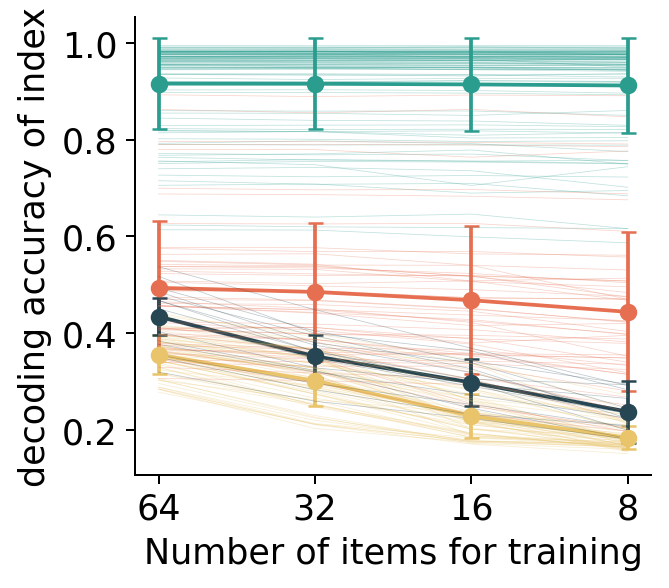

In [88]:
# mean item invariance accuracy of each strategy

item_invariance_accuracy_mean = []
item_invariance_accuracy_std = []
for i in range(3):
    item_invariance_data = df_filtered[df_filtered["cluster"] == i]["item_invariance_accuracy"]
    item_invariance_data = np.stack(item_invariance_data)
    item_invariance_accuracy_mean.append(np.mean(item_invariance_data, axis=0))
    item_invariance_accuracy_std.append(np.std(item_invariance_data, axis=0))

item_invariance_accuracy_mean_reservoir = df_reservoir["item_invariance_accuracy"].mean()
item_invariance_accuracy_std_reservoir = np.std(np.array(df_reservoir["item_invariance_accuracy"]))

# print(item_invariance_accuracy_mean, item_invariance_accuracy_std)

plt.figure(figsize=(3.7, 3.3), dpi=180)
plt.plot(item_invariance_accuracy_mean[0][::-1], color=colormap[0])
plt.errorbar(range(len(item_invariance_accuracy_mean[0])), item_invariance_accuracy_mean[0][::-1], yerr=item_invariance_accuracy_std[0][::-1], fmt='o', color=colormap[0], capsize=3)
plt.plot(item_invariance_accuracy_mean[1][::-1], color=colormap[1])
plt.errorbar(range(len(item_invariance_accuracy_mean[1])), item_invariance_accuracy_mean[1][::-1], yerr=item_invariance_accuracy_std[1][::-1], fmt='o', color=colormap[1], capsize=3)
plt.plot(item_invariance_accuracy_mean[2][::-1], color=colormap[2])
plt.errorbar(range(len(item_invariance_accuracy_mean[2])), item_invariance_accuracy_mean[2][::-1], yerr=item_invariance_accuracy_std[2][::-1], fmt='o', color=colormap[2], capsize=3)
plt.plot(item_invariance_accuracy_mean_reservoir[::-1], color=colormap[-1])
plt.errorbar(range(len(item_invariance_accuracy_mean_reservoir)), item_invariance_accuracy_mean_reservoir[::-1], yerr=item_invariance_accuracy_std_reservoir, fmt='o', color=colormap[-1], capsize=3)
for i in range(3):
    item_invariance_data = df_filtered[df_filtered["cluster"] == i]["item_invariance_accuracy"]
    item_invariance_data = np.stack(item_invariance_data)
    for j in range(len(item_invariance_data)):
        plt.plot(item_invariance_data[j][::-1], color=colormap[i], linestyle='-', linewidth=0.3, alpha=0.3)
for j in range(len(df_reservoir)):
    plt.plot(df_reservoir["item_invariance_accuracy"].iloc[j][::-1], color=colormap[-1], linestyle='-', linewidth=0.3, alpha=0.3)
plt.xlabel("Number of items for training")
plt.ylabel("decoding accuracy of index")
ax = plt.gca()
ax.set_xticks(range(4), [64, 32, 16, 8])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


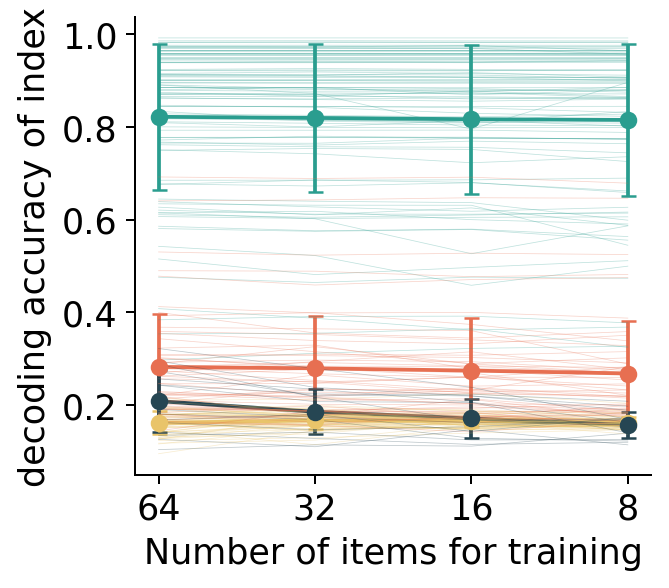

In [19]:
# mean item invariance accuracy of each strategy

item_invariance_accuracy_mean = []
item_invariance_accuracy_std = []
for i in range(3):
    item_invariance_data = df_filtered[df_filtered["cluster"] == i]["item_invariance_cross_phase_accuracy"]
    item_invariance_data = np.stack(item_invariance_data)
    item_invariance_accuracy_mean.append(np.mean(item_invariance_data, axis=0))
    item_invariance_accuracy_std.append(np.std(item_invariance_data, axis=0))

item_invariance_accuracy_mean_reservoir = df_reservoir["item_invariance_cross_phase_accuracy"].mean()
item_invariance_accuracy_std_reservoir = np.std(np.array(df_reservoir["item_invariance_cross_phase_accuracy"]))

# print(item_invariance_accuracy_mean, item_invariance_accuracy_std)

plt.figure(figsize=(3.7, 3.3), dpi=180)
plt.plot(item_invariance_accuracy_mean[0][::-1], color=colormap[0])
plt.errorbar(range(len(item_invariance_accuracy_mean[0])), item_invariance_accuracy_mean[0][::-1], yerr=item_invariance_accuracy_std[0][::-1], fmt='o', color=colormap[0], capsize=3)
plt.plot(item_invariance_accuracy_mean[1][::-1], color=colormap[1])
plt.errorbar(range(len(item_invariance_accuracy_mean[1])), item_invariance_accuracy_mean[1][::-1], yerr=item_invariance_accuracy_std[1][::-1], fmt='o', color=colormap[1], capsize=3)
plt.plot(item_invariance_accuracy_mean[2][::-1], color=colormap[2])
plt.errorbar(range(len(item_invariance_accuracy_mean[2])), item_invariance_accuracy_mean[2][::-1], yerr=item_invariance_accuracy_std[2][::-1], fmt='o', color=colormap[2], capsize=3)
plt.plot(item_invariance_accuracy_mean_reservoir[::-1], color=colormap[-1])
plt.errorbar(range(len(item_invariance_accuracy_mean_reservoir)), item_invariance_accuracy_mean_reservoir[::-1], yerr=item_invariance_accuracy_std_reservoir[::-1], fmt='o', color=colormap[-1], capsize=3)
for i in range(3):
    item_invariance_data = df_filtered[df_filtered["cluster"] == i]["item_invariance_cross_phase_accuracy"]
    item_invariance_data = np.stack(item_invariance_data)
    for j in range(len(item_invariance_data)):
        plt.plot(item_invariance_data[j][::-1], color=colormap[i], linestyle='-', linewidth=0.3, alpha=0.3)
for j in range(len(df_reservoir)):
    plt.plot(df_reservoir["item_invariance_cross_phase_accuracy"].iloc[j][::-1], color=colormap[-1], linestyle='-', linewidth=0.3, alpha=0.3)
plt.xlabel("Number of items for training")
plt.ylabel("decoding accuracy of index")
ax = plt.gca()
ax.set_xticks(range(4), [64, 32, 16, 8])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


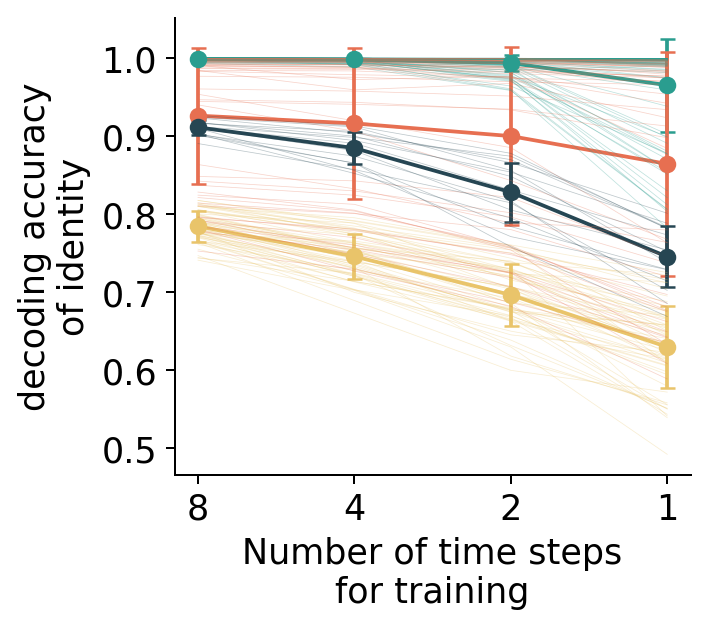

In [91]:
# mean item invariance accuracy of each strategy

time_invariance_accuracy_mean = []
time_invariance_accuracy_std = []
for i in range(3):
    time_invariance_data = df_filtered[df_filtered["cluster"] == i]["time_invariance_accuracy"]
    time_invariance_data = np.stack(time_invariance_data)
    time_invariance_accuracy_mean.append(np.mean(time_invariance_data, axis=0))
    time_invariance_accuracy_std.append(np.std(time_invariance_data, axis=0))

time_invariance_accuracy_mean_reservoir = df_reservoir["time_invariance_accuracy"].mean()
time_invariance_accuracy_std_reservoir = np.std(np.array(df_reservoir["time_invariance_accuracy"]))

# print(item_invariance_accuracy_mean, item_invariance_accuracy_std)

plt.figure(figsize=(3.7, 3.3), dpi=180)
plt.plot(time_invariance_accuracy_mean[0][::-1], color=colormap[0])
plt.errorbar(range(len(time_invariance_accuracy_mean[0])), time_invariance_accuracy_mean[0][::-1], yerr=time_invariance_accuracy_std[0][::-1], fmt='o', color=colormap[0], capsize=3)
plt.plot(time_invariance_accuracy_mean[1][::-1], color=colormap[1])
plt.errorbar(range(len(time_invariance_accuracy_mean[1])), time_invariance_accuracy_mean[1][::-1], yerr=time_invariance_accuracy_std[1][::-1], fmt='o', color=colormap[1], capsize=3)
plt.plot(time_invariance_accuracy_mean[2][::-1], color=colormap[2])
plt.errorbar(range(len(time_invariance_accuracy_mean[2])), time_invariance_accuracy_mean[2][::-1], yerr=time_invariance_accuracy_std[2][::-1], fmt='o', color=colormap[2], capsize=3)
plt.plot(time_invariance_accuracy_mean_reservoir[::-1], color=colormap[-1])
plt.errorbar(range(len(time_invariance_accuracy_mean_reservoir)), time_invariance_accuracy_mean_reservoir[::-1], yerr=time_invariance_accuracy_std_reservoir[::-1], fmt='o', color=colormap[-1], capsize=3)
for i in range(3):
    time_invariance_data = df_filtered[df_filtered["cluster"] == i]["time_invariance_accuracy"]
    time_invariance_data = np.stack(time_invariance_data)
    for j in range(len(time_invariance_data)):
        plt.plot(time_invariance_data[j][::-1], color=colormap[i], linestyle='-', linewidth=0.3, alpha=0.3)
for j in range(len(df_reservoir)):
    plt.plot(df_reservoir["time_invariance_accuracy"].iloc[j][::-1], color=colormap[-1], linestyle='-', linewidth=0.3, alpha=0.3)
plt.xlabel("Number of time steps\nfor training")
plt.ylabel("decoding accuracy\nof identity")
ax = plt.gca()
ax.set_xticks(range(4), [8, 4, 2, 1])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


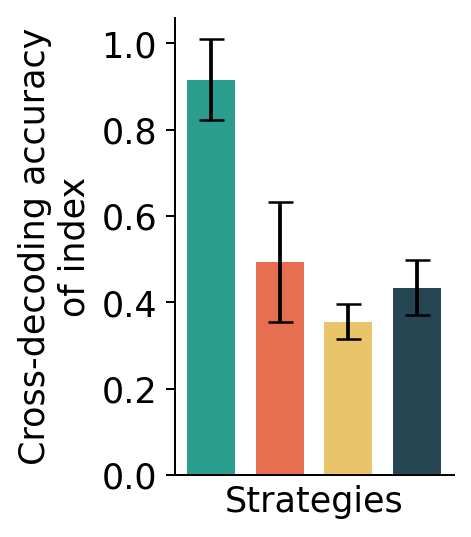

In [97]:
item_invariance_accuracy_mean_all = np.array([item_invariance_accuracy_mean[0][-1], item_invariance_accuracy_mean[1][-1], item_invariance_accuracy_mean[2][-1], item_invariance_accuracy_mean_reservoir[-1]])
item_invariance_accuracy_std_all = np.array([item_invariance_accuracy_std[0][-1], item_invariance_accuracy_std[1][-1], item_invariance_accuracy_std[2][-1], item_invariance_accuracy_std_reservoir[-1]])

plt.figure(figsize=(2, 3.3), dpi=180)
bar_width = 0.7
plt.bar(range(4), item_invariance_accuracy_mean_all[[1,2,0,3]], bar_width, yerr=item_invariance_accuracy_std_all[[1,2,0,3]], capsize=5, color=colormap[[1,2,0,-1]])
plt.xlabel("Strategies")
plt.ylabel("Cross-decoding accuracy\nof index")
ax = plt.gca()
# ax.set_xticks(range(3), ["Strategy 1", "Strategy 2", "Strategy 3"])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

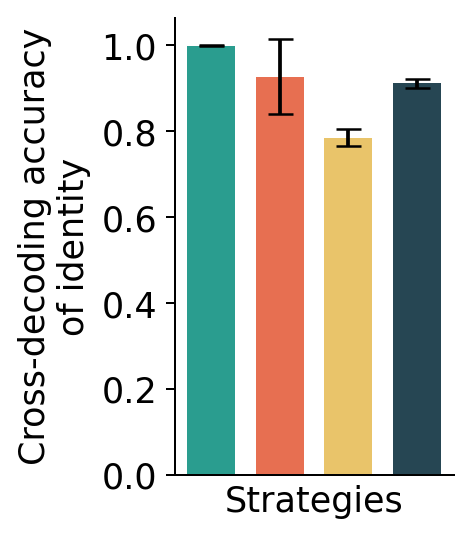

In [92]:
time_invariance_accuracy_mean_all = np.array([time_invariance_accuracy_mean[0][-1], time_invariance_accuracy_mean[1][-1], time_invariance_accuracy_mean[2][-1], time_invariance_accuracy_mean_reservoir[-1]])
time_invariance_accuracy_std_all = np.array([time_invariance_accuracy_std[0][-1], time_invariance_accuracy_std[1][-1], time_invariance_accuracy_std[2][-1], time_invariance_accuracy_std_reservoir[-1]])

plt.figure(figsize=(2, 3.3), dpi=180)
bar_width = 0.7
plt.bar(range(4), time_invariance_accuracy_mean_all[[1,2,0,3]], bar_width, yerr=time_invariance_accuracy_std_all[[1,2,0,3]], capsize=5, color=colormap[[1,2,0,-1]])
plt.xlabel("Strategies")
plt.ylabel("Cross-decoding accuracy\nof identity")
ax = plt.gca()
# ax.set_xticks(range(3), ["Strategy 1", "Strategy 2", "Strategy 3"])
ax.set_xticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

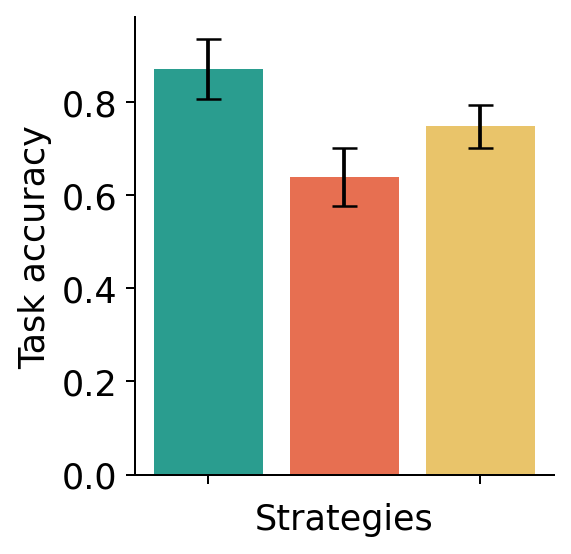

In [98]:
# performance of each strategy

# df_tdf_filtered = df_filtered[(df_filtered["noise_level"] == 1.0) & (df_filtered["temporal_factor"] >= 0.4)]

df_grouped_by_cluster = df_filtered.groupby("cluster")

accuracy = df_grouped_by_cluster["accuracy"].mean()

accuracy_std = df_grouped_by_cluster["accuracy"].std()


plt.figure(figsize=(3, 3.3), dpi=180)
plt.bar(accuracy.index, accuracy.values[[1,2,0]], color=colormap[accuracy.index[[1,2,0]]], yerr=accuracy_std.values[[1,2,0]], capsize=5)
ax = plt.gca()
ax.set_xticklabels([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Strategies")
plt.ylabel("Task accuracy")
plt.show()






### performance with fixed hyperparams

In [179]:
features = ["forward_asymmetry", "temporal_factor",
            # "index_decoding_accuracy", "item_decoding_accuracy", "last_item_decoding_accuracy", 
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity"]

# print(df_perf1_filtered.keys())
# print(df_perf2_filtered.keys())


# df_perf1_filtered = df_perf1[(df_perf1["temporal_factor"] >= 0.35)]
# df_perf2_filtered = df_perf2[(df_perf2["temporal_factor"] >= 0.35)]
df_perf1_filtered = df_perf1
df_perf2_filtered = df_perf2

X_perf1 = df_perf1_filtered[features]
X_perf2 = df_perf2_filtered[features]

X_perf1_normalized = scaler.transform(X_perf1)
X_perf2_normalized = scaler.transform(X_perf2)

cluster_labels_perf1 = kmeans.predict(X_perf1_normalized)
cluster_labels_perf2 = kmeans.predict(X_perf2_normalized)

df_perf1_filtered.loc[:, "cluster"] = cluster_labels_perf1
df_perf2_filtered.loc[:, "cluster"] = cluster_labels_perf2

print(cluster_labels_perf1)
print(cluster_labels_perf2)

print(df_perf1_filtered["cluster"].value_counts())
print(df_perf2_filtered["cluster"].value_counts())






[1 2 1 2 2 1 2 1 0 1 0 1 2 2 2 2 2 0 1 2 1 2 2 0 2 2 1 2 2 2 1 2 2 2 1 2 1
 2 1 1 0 1 2 0 2 1 2 2 1 2 2 2 1 0 2 2 1 2 1 2 2 2 1 2 2 1 2 2 1 2 2 2 1 2
 1 2 1 2 2 2 1 2 2 1 2 1 0 1 2 0 0 2 2 1 0 2 1]
[0 2 2 2 2 0 2 2 2 1 0 0 2 2 2 2 2 2 2 2 2 1 2 0 0 2 2 0 2 2 0 0 2 2 2 0 2
 0 2 2 0 2 2 2 2 2 2 2 0 2 2 2 0 1 2 2 0 2 1 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2
 2 0 2 0 2 1 2 0 2 2 1 2 2 2 0 2 2 2 2 2 2 2 1 0 2 0]
cluster
2    54
1    32
0    11
Name: count, dtype: int64
cluster
2    71
0    22
1     7
Name: count, dtype: int64


In [172]:
# performance scatter
colormap = {
    "forward_asymmetry": "tab:purple",
    "temporal_factor": "tab:blue",
    "explained_variance": "tab:green",
    "cross_decoding": "tab:orange",
    "accuracy": "black"
}


def plot_scatter(df, x, y, x_label, y_label, color):
    plt.figure(figsize=(3.4, 3.3), dpi=180)

    plt.scatter(df[x], df[y], color=color, alpha=0.7)
    
    # Reshape x and y for sklearn
    x_reshaped = np.array(df[x]).reshape(-1, 1)
    y_reshaped = np.array(df[y]).reshape(-1, 1)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(x_reshaped, y_reshaped)

    # Predict y values
    sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
    x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
    y_pred = model.predict(x_reshaped)
    y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

    # Calculate R-squared
    r2 = r2_score(y_reshaped, y_pred)
    # Calculate the p-value for the regression
    _, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())
    
    # Plot the regression line
    plt.plot([x1, x2], [y1, y2], color="grey")

    plt.xlabel(x_label+"\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value))
    plt.ylabel(y_label)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()
    

In [ ]:
plot_scatter(df_perf1, "forward_asymmetry", "accuracy", "Forward asymmetry", "Task accuracy", colormap["forward_asymmetry"])
plot_scatter(df_perf1, "temporal_factor", "accuracy", "Temporal factor", "Task accuracy", colormap["temporal_factor"])
plot_scatter(df_perf1, "explained_variance_index", "accuracy", "Variance explained (index)", "Task accuracy", colormap["explained_variance"])
plot_scatter(df_perf1, "cross_decoding_accuracy_index", "accuracy", "Cross decoding accuracy\n(index)", "Task accuracy", colormap["cross_decoding"])


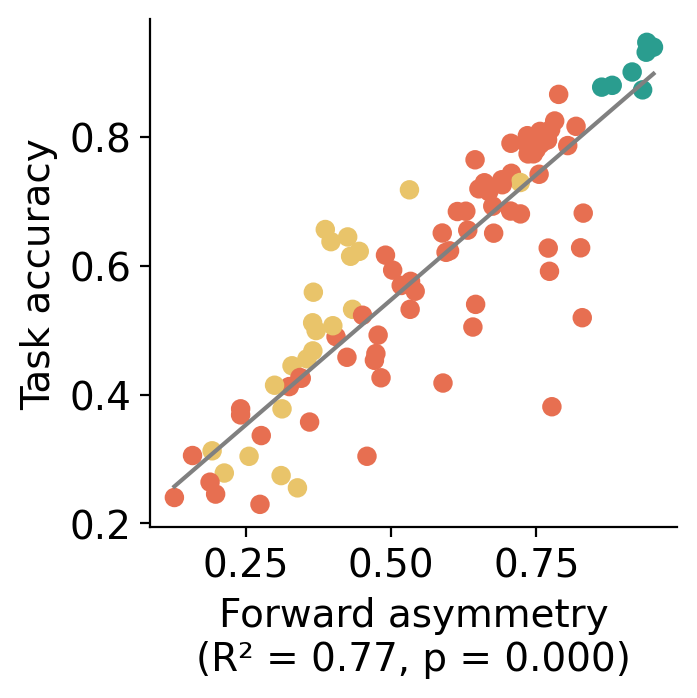

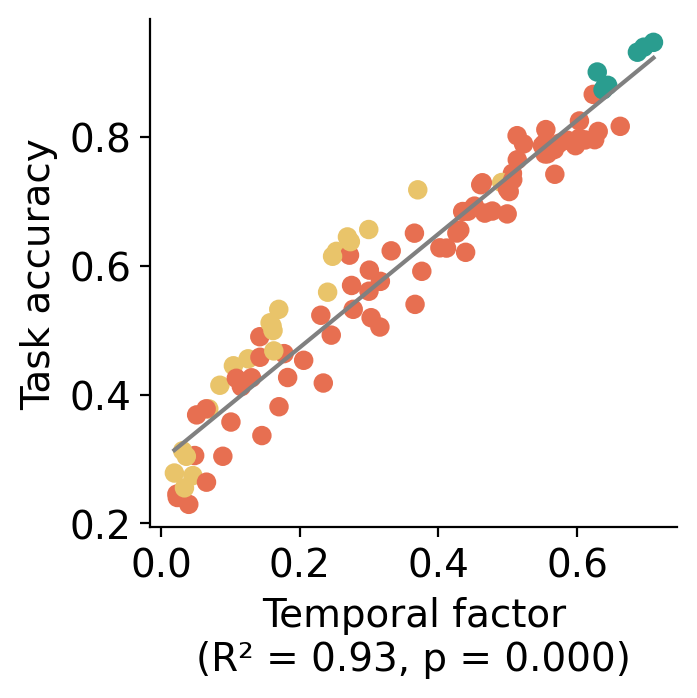

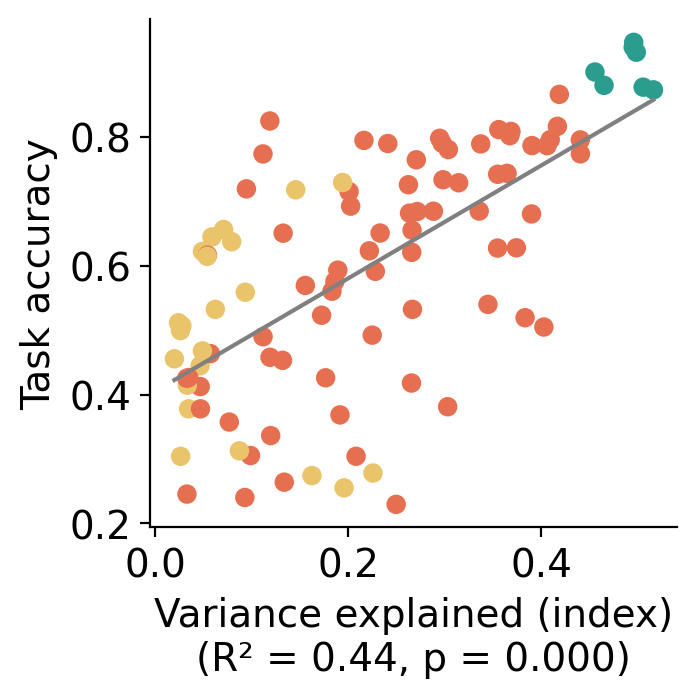

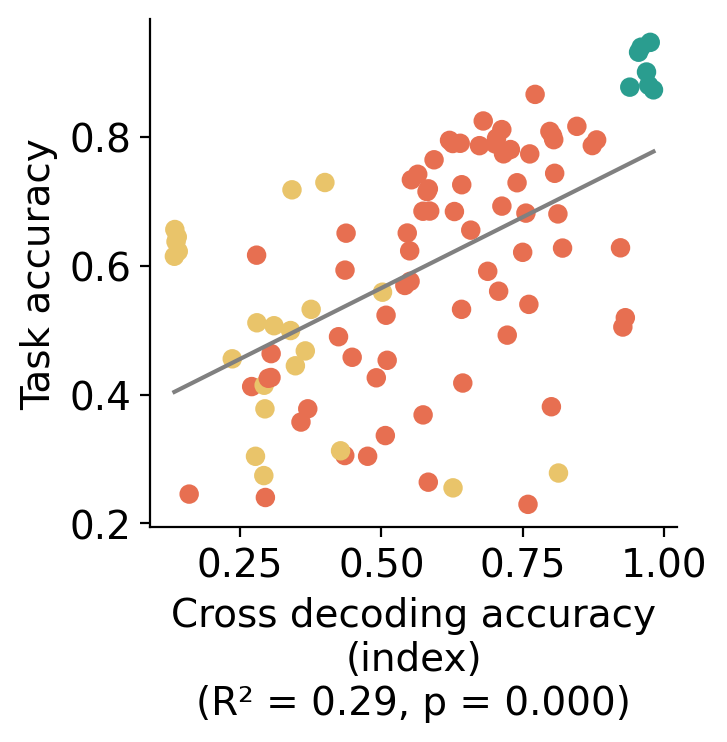

In [181]:
# plot_scatter_cluster(df_perf1_filtered, "forward_asymmetry", "accuracy", "cluster", "Forward asymmetry", "Task accuracy", fit=False)
plot_scatter_cluster(df_perf2_filtered, "forward_asymmetry", "accuracy", "cluster", "Forward asymmetry", "Task accuracy", fit=True, plot_reservoir=False)
plot_scatter_cluster(df_perf2_filtered, "temporal_factor", "accuracy", "cluster", "Temporal factor", "Task accuracy", fit=True, plot_reservoir=False)
plot_scatter_cluster(df_perf2_filtered, "explained_variance_index", "accuracy", "cluster", "Variance explained (index)", "Task accuracy", fit=True, plot_reservoir=False)
plot_scatter_cluster(df_perf2_filtered, "cross_decoding_accuracy_index", "accuracy", "cluster", "Cross decoding accuracy\n(index)", "Task accuracy", fit=True, plot_reservoir=False)


### metrics with performance

In [37]:
colormap = {
    "forward_asymmetry": "tab:purple",
    "temporal_factor": "tab:blue",
    "explained_variance": "tab:green",
    "cross_decoding": "tab:orange",
    "accuracy": "black"
}

In [ ]:
from matplotlib.colors import ListedColormap

def plot_scatter_by_group(df, x, y, c, x_label, y_label, colormap_label, colormap='viridis'):
    plt.figure(figsize=(4.3, 3.3), dpi=180)
    
    colors = plt.get_cmap(colormap)(np.linspace(0, 1, len(df[c].unique())))
    
    group_unique_values = df[c].unique()
    for i, group in enumerate(group_unique_values):
        group_data = df[df[c] == group]
        plt.scatter(group_data[x], group_data[y], color=colors[i], label=colormap_label+"="+str(group))

    # Reshape x and y for sklearn
    x_reshaped = np.array(df[x]).reshape(-1, 1)
    y_reshaped = np.array(df[y]).reshape(-1, 1)

    # Fit linear regression model
    model = LinearRegression()
    model.fit(x_reshaped, y_reshaped)

    # Predict y values
    sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
    x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
    y_pred = model.predict(x_reshaped)
    y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

    # Calculate R-squared
    r2 = r2_score(y_reshaped, y_pred)
    # Calculate the p-value for the regression
    _, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())
    
    # Plot the regression line
    plt.plot([x1, x2], [y1, y2], color="grey")

    plt.xlabel(x_label+"\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value))
    plt.ylabel(y_label)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)

    cmap = ListedColormap(colors)
    norm = plt.Normalize(vmin=np.min(group_unique_values) - 0.1, vmax=np.max(group_unique_values) + 0.1)
    plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ticks=group_unique_values, label=colormap_label, ax=ax)

    plt.show()

In [ ]:
df_tdf_filtered = df[(df["noise_level"] == 1.0) & (df["temporal_factor"] >= 0.4)]
print(len(df_tdf_filtered))

102


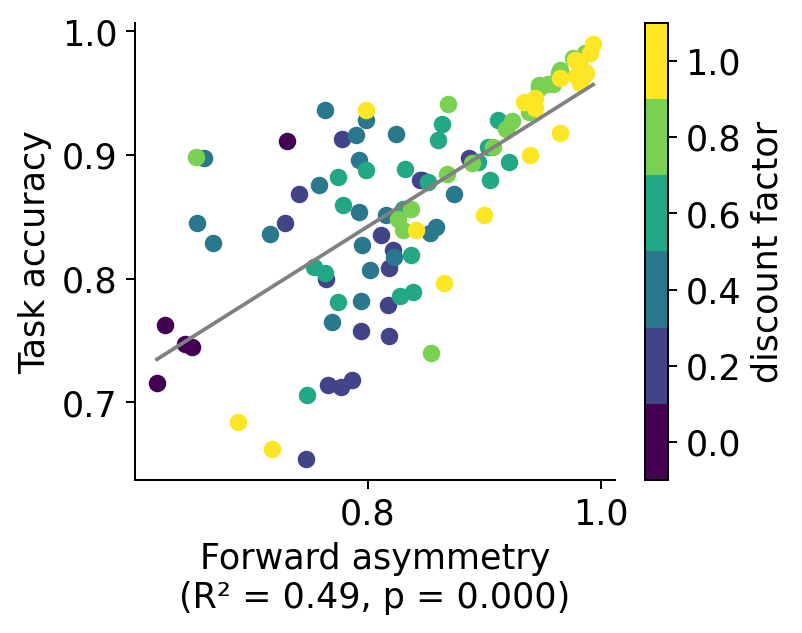

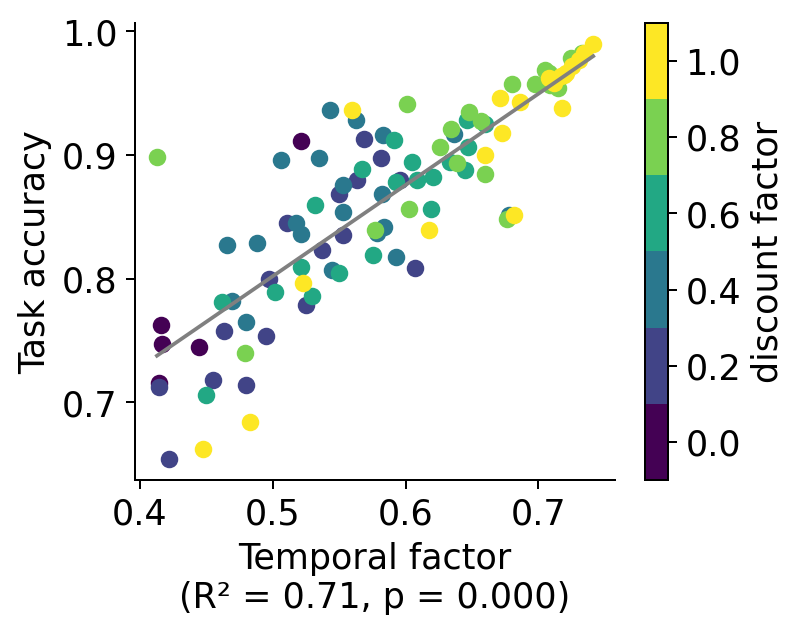

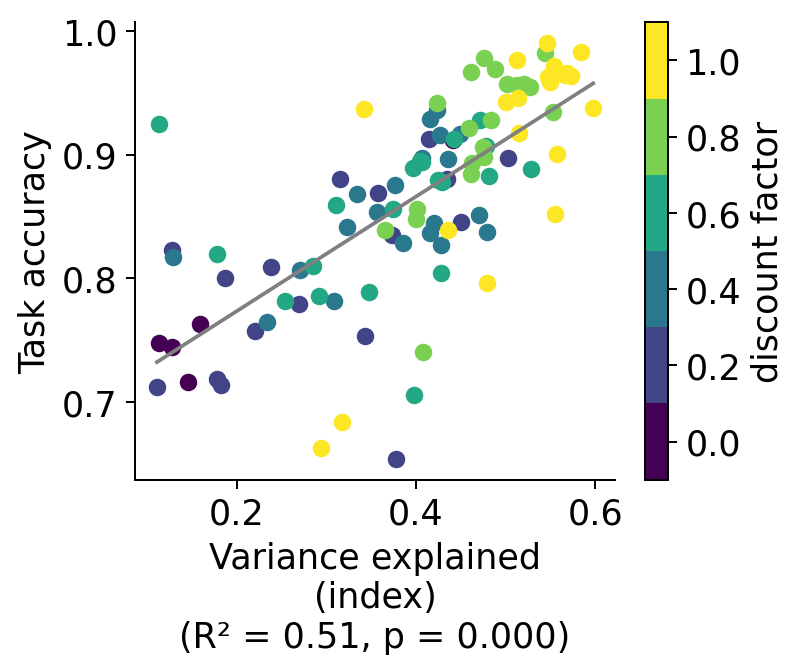

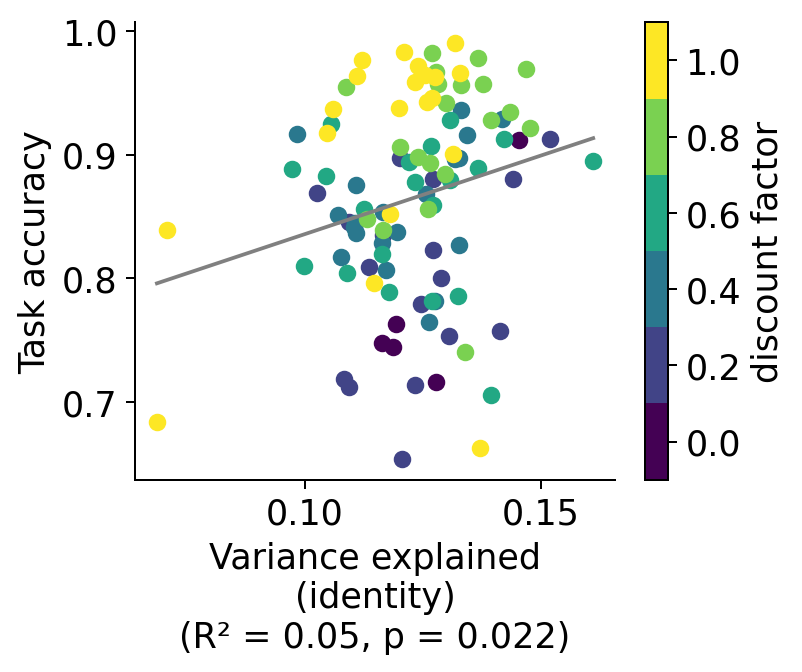

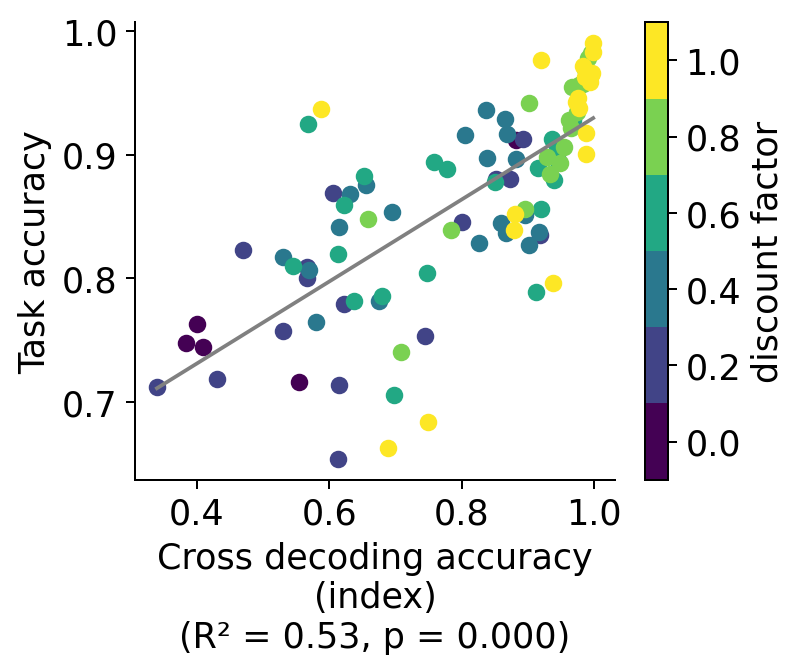

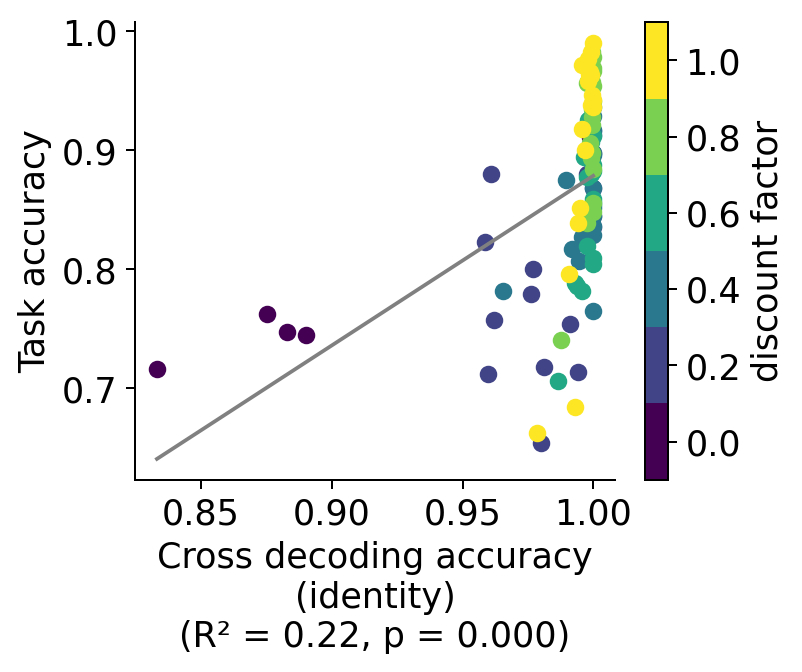

In [ ]:
# metrics and accuracy
plot_scatter_by_group(df_tdf_filtered, "forward_asymmetry", "accuracy", "temporal_discount_factor", "Forward asymmetry", "Task accuracy", "discount factor")
plot_scatter_by_group(df_tdf_filtered, "temporal_factor", "accuracy", "temporal_discount_factor", "Temporal factor", "Task accuracy", "discount factor")
plot_scatter_by_group(df_tdf_filtered, "explained_variance_index", "accuracy", "temporal_discount_factor", "Variance explained\n(index)", "Task accuracy", "discount factor")
plot_scatter_by_group(df_tdf_filtered, "explained_variance_identity", "accuracy", "temporal_discount_factor", "Variance explained\n(identity)", "Task accuracy", "discount factor")
plot_scatter_by_group(df_tdf_filtered, "cross_decoding_accuracy_index", "accuracy", "temporal_discount_factor", "Cross decoding accuracy\n(index)", "Task accuracy", "discount factor")
plot_scatter_by_group(df_tdf_filtered, "cross_decoding_accuracy_identity", "accuracy", "temporal_discount_factor", "Cross decoding accuracy\n(identity)", "Task accuracy", "discount factor")


In [ ]:
df_noise_filtered = df[(df["temporal_discount_factor"] == 1.0) & (df["temporal_factor"] >= 0.4)]
print(len(df_noise_filtered))

89


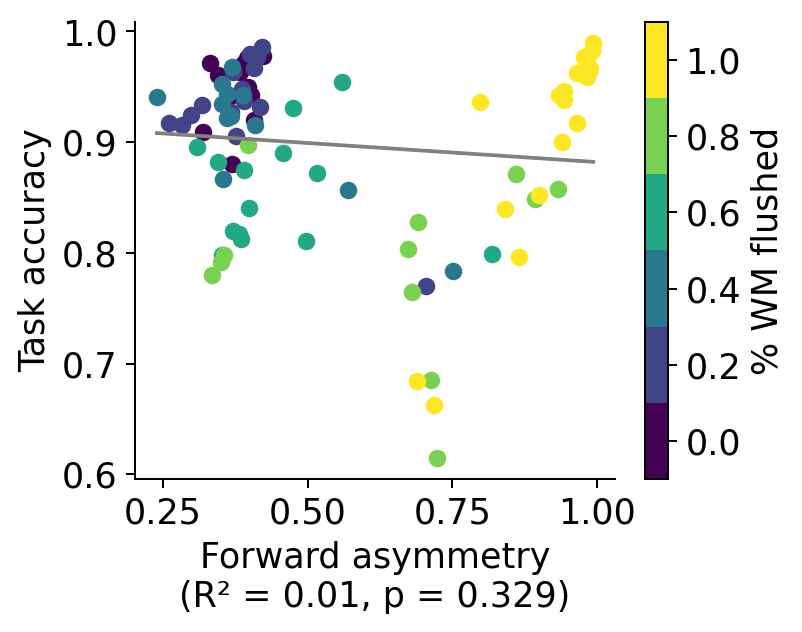

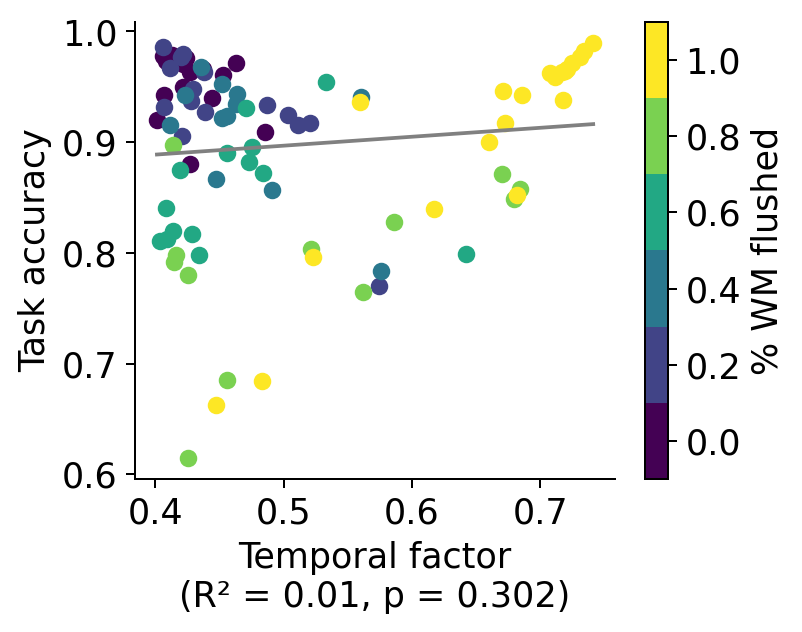

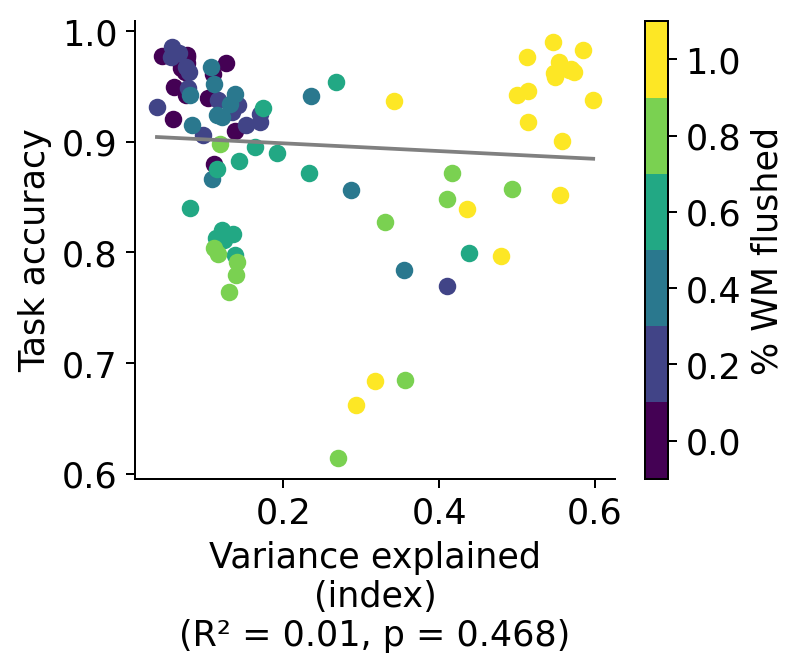

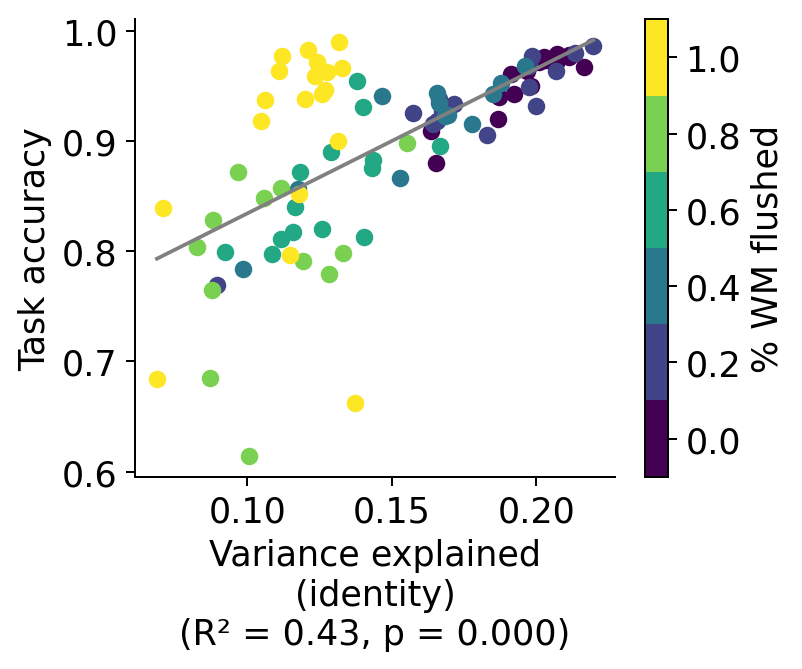

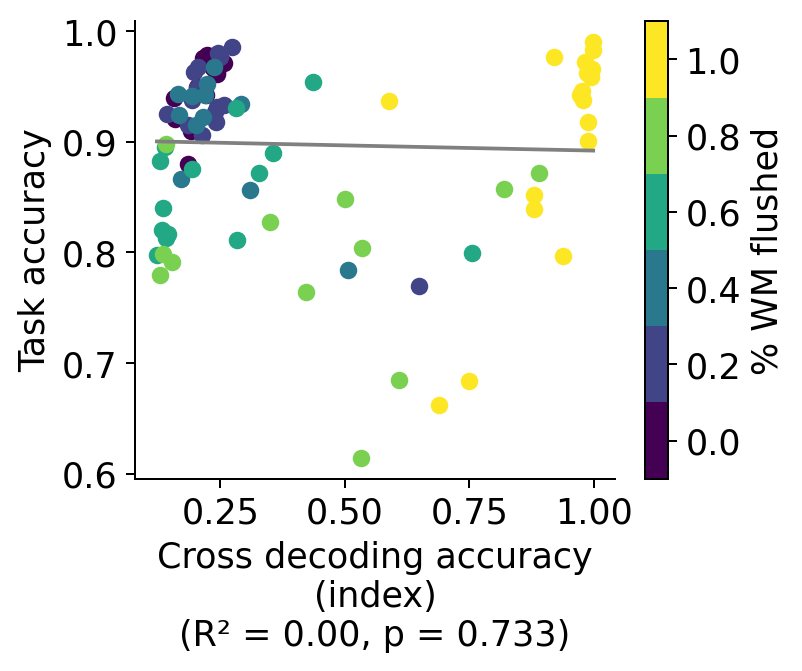

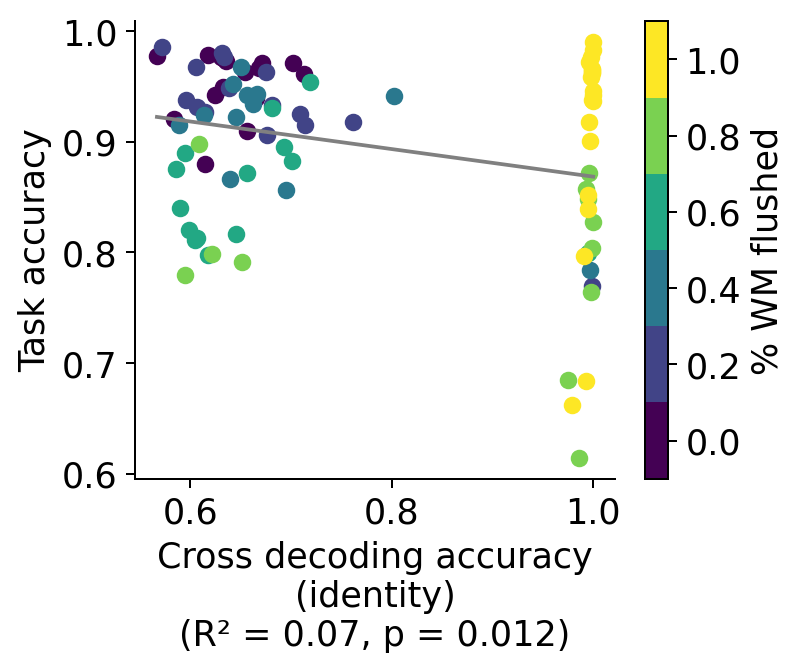

In [ ]:
plot_scatter_by_group(df_noise_filtered, "forward_asymmetry", "accuracy", "noise_level", "Forward asymmetry", "Task accuracy", "% WM flushed")
plot_scatter_by_group(df_noise_filtered, "temporal_factor", "accuracy", "noise_level", "Temporal factor", "Task accuracy", "% WM flushed")
plot_scatter_by_group(df_noise_filtered, "explained_variance_index", "accuracy", "noise_level", "Variance explained\n(index)", "Task accuracy", "% WM flushed")
plot_scatter_by_group(df_noise_filtered, "explained_variance_identity", "accuracy", "noise_level", "Variance explained\n(identity)", "Task accuracy", "% WM flushed")
plot_scatter_by_group(df_noise_filtered, "cross_decoding_accuracy_index", "accuracy", "noise_level", "Cross decoding accuracy\n(index)", "Task accuracy", "% WM flushed")
plot_scatter_by_group(df_noise_filtered, "cross_decoding_accuracy_identity", "accuracy", "noise_level", "Cross decoding accuracy\n(identity)", "Task accuracy", "% WM flushed")


### perturbation

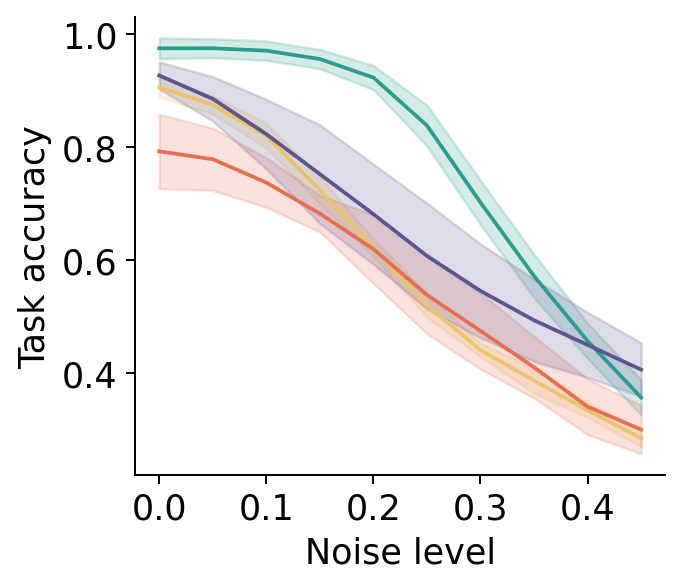

In [68]:
# df_filtered_new = df_filtered[df_filtered["accuracy"] > 0.9]
# Get the 10 models with the highest accuracy for each cluster
top_models_per_cluster = {}

for cluster_id in range(3):
    # Filter the models belonging to the current cluster
    cluster_models = df_filtered[df_filtered["cluster"] == cluster_id]
    
    # Sort the models by accuracy in descending order
    sorted_models = cluster_models.sort_values(by="accuracy", ascending=False)
    
    # Select the top 10 models
    top_models = sorted_models.head(10)
    
    # Store the result in the dictionary
    top_models_per_cluster[cluster_id] = top_models

# Convert the dictionary of top models per cluster into a DataFrame
top_models_df = pd.concat(top_models_per_cluster.values(), keys=top_models_per_cluster.keys(), names=['cluster_id', 'model_index']).reset_index(level='model_index', drop=True).reset_index()

df_filtered_new = top_models_df

perturbation_data = [[] for i in range(3)]
for i in range(3):
    perturbation_data[i] = df_filtered_new[df_filtered_new["cluster"] == i]["perturbation_accuracy"].to_numpy()
    perturbation_data[i] = np.stack(perturbation_data[i])

perturbation_data_mean = [np.mean(perturbation_data[i], axis=0) for i in range(3)]
perturbation_data_std = [np.std(perturbation_data[i], axis=0) for i in range(3)]

perturbation_data_tcm = df_tcm["perturbation_accuracy"].to_numpy()
perturbation_data_tcm = np.stack(perturbation_data_tcm)
perturbation_data_tcm_mean = np.mean(perturbation_data_tcm, axis=0)
perturbation_data_tcm_std = np.std(perturbation_data_tcm, axis=0)

plt.figure(figsize=(3.8, 3.3), dpi=180)
xaxis = np.linspace(0, 1, 21)
plt.plot(xaxis[:10], perturbation_data_mean[0][:10], color=colormap[0], label="Cluster 0")
plt.fill_between(xaxis[:10], perturbation_data_mean[0][:10] - perturbation_data_std[0][:10], perturbation_data_mean[0][:10] + perturbation_data_std[0][:10], color=colormap[0], alpha=0.2)
plt.plot(xaxis[:10], perturbation_data_mean[1][:10], color=colormap[1], label="Cluster 1")
plt.fill_between(xaxis[:10], perturbation_data_mean[1][:10] - perturbation_data_std[1][:10], perturbation_data_mean[1][:10] + perturbation_data_std[1][:10], color=colormap[1], alpha=0.2)
plt.plot(xaxis[:10], perturbation_data_mean[2][:10], color=colormap[2], label="Cluster 2")
plt.fill_between(xaxis[:10], perturbation_data_mean[2][:10] - perturbation_data_std[2][:10], perturbation_data_mean[2][:10] + perturbation_data_std[2][:10], color=colormap[2], alpha=0.2)
plt.plot(xaxis[:10], perturbation_data_tcm_mean[:10], color="#5E548E", label="TCM")
plt.fill_between(xaxis[:10], perturbation_data_tcm_mean[:10] - perturbation_data_tcm_std[:10], perturbation_data_tcm_mean[:10] + perturbation_data_tcm_std[:10], color="#5E548E", alpha=0.2)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel("Noise level")
plt.ylabel("Task accuracy")
plt.show()




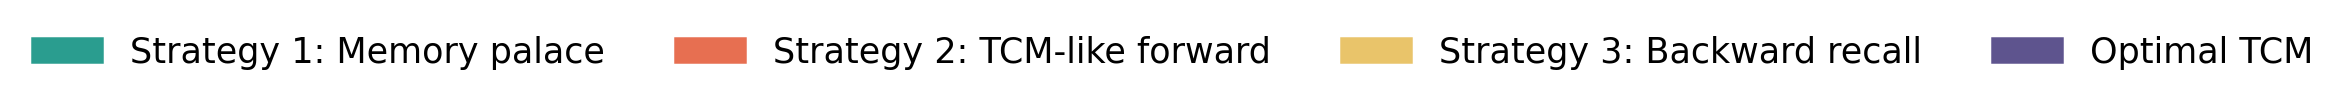

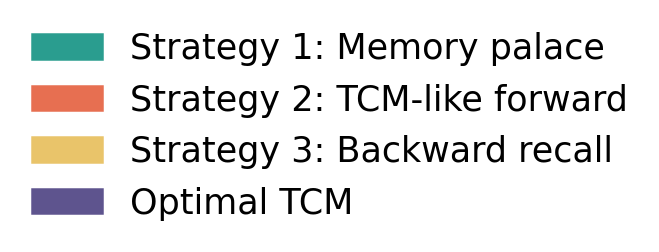

In [69]:
# Create a legend for the colormap
import matplotlib.patches as mpatches

# Define labels for the legend
legend_labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

# Create a list of patches for the legend
patches = [mpatches.Patch(color="#2A9D8F", label="Strategy 1: Memory palace"),
           mpatches.Patch(color="#E76F51", label="Strategy 2: TCM-like forward"),
           mpatches.Patch(color="#E9C46A", label="Strategy 3: Backward recall"),
           mpatches.Patch(color="#5E548E", label="Optimal TCM")]
        #    mpatches.Patch(color="#264653", label="TCM")]
# [mpatches.Patch(color=colormap[i], label=legend_labels[i]) for i in range(optimal_clusters)]

# Plot the legend
plt.figure(figsize=(8, 0.5), dpi=180)
plt.legend(handles=patches, loc='center', ncol=optimal_clusters+1, frameon=False)
plt.axis('off')
plt.show()

plt.figure(figsize=(2, 0.5), dpi=180)
plt.legend(handles=patches, loc='center', frameon=False)
plt.axis('off')
plt.show()

### noise

In [70]:
""" load no noise data """

data = []

data_folder = Path("./experiments/VaryAllSeq8NoNoise/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/VaryAllSeq8NoNoise/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/VaryAllSeq8NoNoise/figures/perturbation/ValueMemoryGRU")
seq_len = 8

exp = "tdf"

for gamma_name, temporal_discount_factor in zip(gamma_names, temporal_discount_factors):
    for noise_name, noise_level in zip(noise_names, noise_levels):
        setup_name = "setup_gamma{}_noise{}".format(gamma_name, noise_name)

        parameters = {
            "temporal_discount_factor": temporal_discount_factor,
            "noise_level": noise_level,
            "seq_len": seq_len,
        }
        
        training_data_length = 200
        for i in range(20):
            data_path = data_folder / setup_name / str(i)
            training_data_path = training_curve_folder / (setup_name + "-" + str(i))
            if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
                data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
                if data_single_model:
                    data_single_model["pretrained"] = False
                    perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                    data_single_model["perturbation_accuracy"] = perturbation_data
                    data.append(data_single_model)

df_no_noise = pd.DataFrame(data)
print(len(data))


708


In [71]:
""" load no noise data """

data = []

data_folder = Path("./experiments/VaryAllSeq8/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/VaryAllSeq8/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/VaryAllSeq8/figures/perturbation/ValueMemoryGRU")
seq_len = 8

exp = "tdf"

for gamma_name, temporal_discount_factor in zip(gamma_names, temporal_discount_factors):
    for noise_name, noise_level in zip(noise_names, noise_levels):
        setup_name = "setup_gamma{}_noise{}".format(gamma_name, noise_name)

        parameters = {
            "temporal_discount_factor": temporal_discount_factor,
            "noise_level": noise_level,
            "seq_len": seq_len,
        }
        
        training_data_length = 200
        for i in range(20):
            data_path = data_folder / setup_name / str(i)
            training_data_path = training_curve_folder / (setup_name + "-" + str(i))
            if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
                data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
                if data_single_model:
                    data_single_model["pretrained"] = False
                    perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                    data_single_model["perturbation_accuracy"] = perturbation_data
                    data.append(data_single_model)

df_less_noise = pd.DataFrame(data)
print(len(data))


717


157 194 196


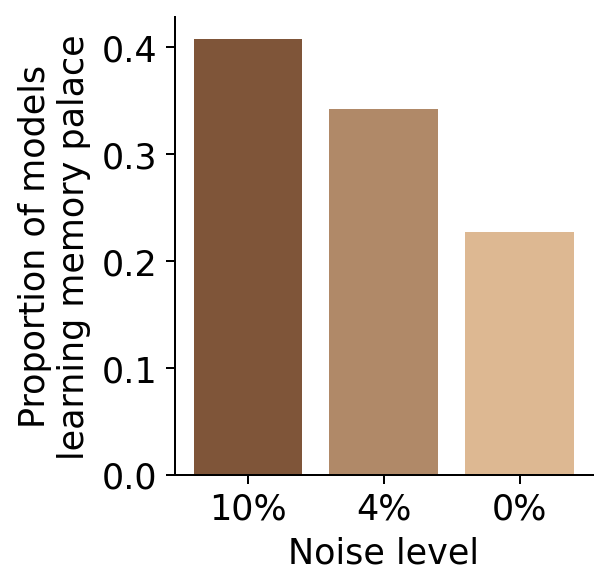

In [76]:
# df_no_noise_filtered = df_no_noise[(df_no_noise["accuracy"] > 0.7) & (df_no_noise["temporal_factor"] >= 0.37)]
# df_filtered = df[(df["accuracy"] > 0.7) & (df["temporal_factor"] >= 0.44)]
df_no_noise_filtered = df_no_noise[((df_no_noise["temporal_discount_factor"] == 1.0) | (df_no_noise["noise_level"] == 1.0)) & (df_no_noise["accuracy"] >= 0.7)]
df_less_noise_filtered = df_less_noise[((df_less_noise["temporal_discount_factor"] == 1.0) | (df_less_noise["noise_level"] == 1.0)) & (df_less_noise["accuracy"] >= 0.7)]
df_large_noise_filtered = df_filtered[(df_filtered["accuracy"] >= 0.7)]
print(len(df_large_noise_filtered), len(df_no_noise_filtered), len(df_less_noise_filtered))

num_memory_palace_large_noise = len((df_large_noise_filtered[(df_large_noise_filtered["explained_variance_index"] >= 0.4)]))
prop_memory_palace_large_noise = num_memory_palace_large_noise / len(df_large_noise_filtered)

num_memory_palace_no_noise = len((df_no_noise_filtered[(df_no_noise_filtered["explained_variance_index"] >= 0.4)]))
prop_memory_palace_no_noise = num_memory_palace_no_noise / len(df_no_noise_filtered)

num_memory_palace_less_noise = len((df_less_noise_filtered[(df_less_noise_filtered["explained_variance_index"] >= 0.4)]))
prop_memory_palace_less_noise = num_memory_palace_less_noise / len(df_less_noise_filtered)

plt.figure(figsize=(3, 3.3), dpi=180)
plt.bar(0, prop_memory_palace_large_noise, color="#7F5539")
plt.bar(1, prop_memory_palace_less_noise, color="#B08968")
plt.bar(2, prop_memory_palace_no_noise, color="#DDB892")


plt.xticks([0, 1, 2], ["10%", "4%", "0%"])
plt.xlabel("Noise level")
# plt.ylabel("Proportion of explained\nvariance of index > 0.4")
plt.ylabel("Proportion of models\nlearning memory palace")
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()